In [3]:


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from IPython.display import clear_output
# numpy and pandas for data manipulation

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')


# matplotlib and seaborn for plotting
import seaborn as sns
import plotly.express as px


from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()


# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src import utils  
from src.config import Config as cfg  


TARGET = cfg.TARGET

# -------------------------------------------------------





sys.path contains: /home/ismail/x42


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [4]:
# -------------------------------
# Load Data
# -------------------------------
from src.data_loader import load_data, prepare_data


X_train, X_test, y_train, y_test = load_data("raw")
# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

# Ensure y is numpy array
y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None

Number of classes: 2
X_train shape: (300000, 23)
X_test shape: (200000, 23)
y_train shape: (300000,)
y_test labels are not available
Test IDs available: 200000


In [5]:
from src.data_splitter import DataSplitter

# ⚠️ If you don’t set folds_path, it will generate new random splits every time you call split().
splitter = DataSplitter(
    method="stratified_kfold",
    n_splits=5,
    random_state=42,
    # random_states=[42, 1337],  # multi-seed CV
    folds_path="data/folds.npy" # folds_xgb.npy?
)

folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))


✅ Loaded 5 folds from data/folds.npy
♻️ Reusing existing folds
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 300000
Total folds: 5

Fold 0: Train size=240000, Val size=60000
Fold 1: Train size=240000, Val size=60000
Fold 2: Train size=240000, Val size=60000
Fold 3: Train size=240000, Val size=60000
Fold 4: Train size=240000, Val size=60000


In [6]:
X_train.columns

Index(['bin_0', 'bin_1', 'bin_2', 'bin_3', 'bin_4', 'nom_0', 'nom_1', 'nom_2',
       'nom_3', 'nom_4', 'nom_5', 'nom_6', 'nom_7', 'nom_8', 'nom_9', 'ord_0',
       'ord_1', 'ord_2', 'ord_3', 'ord_4', 'ord_5', 'day', 'month'],
      dtype='object')

In [7]:
bin_cols = ['bin_0', 'bin_1', 'bin_2', 'bin_3', 'bin_4']
nom_cols = ['nom_0', 'nom_1', 'nom_2', 'nom_3', 'nom_4']
ord_cols = ['ord_0', 'ord_1', 'ord_2', 'ord_3']
date_cols = ['day', 'month']
high_card_feats = ['nom_5', 'nom_6', 'nom_7', 'nom_8', 'nom_9']

### Generate WOE Features via KMeans Clustering (numeric)


#### **General Idea / Purpose:**

This function creates **new numerical features** from existing numerical columns by:

1. **Clustering each numerical feature** using KMeans to group similar values.
2. **Computing Weight of Evidence (WOE)** for each cluster based on the target variable.
3. **Mapping the WOE values** back to train and test sets as new features.
4. Optionally **evaluating each generated feature** using cross-validated ROC AUC to gauge its predictive strength.
5. Returning the new WOE features for train and test, ready to be added to a model.

**Key points:**

* Focuses purely on **model improvement**, not interpretability.
* Works with any list of numerical features.
* Automatically handles missing values and scales features before clustering.
* Returns the names of the new features for easy integration into downstream pipelines.



In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from prettytable import PrettyTable

def create_cluster_woe_features(X_train, y_train, X_test, num_features, n_clusters=5, cv_splits=5, verbose=True):
    """
    Generate WOE features based on clustering numerical features.

    Parameters:
    -----------
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Target variable for training.
    X_test : pd.DataFrame
        Test features.
    num_features : list
        List of numerical features to transform.
    n_clusters : int, default=5
        Number of clusters per feature.
    cv_splits : int, default=5
        Number of CV folds for evaluating each feature.
    verbose : bool, default=True
        Whether to print a PrettyTable of feature CV scores.

    Returns:
    --------
    X_train_woe_final : pd.DataFrame
        Training set with new WOE features.
    X_test_woe_final : pd.DataFrame
        Test set with new WOE features.
    woe_feature_names : list
        List of names of new WOE features.
    """
    
    X_train_feat = X_train.copy()
    X_test_feat = X_test.copy()
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    
    overall_best_score = -np.inf
    overall_best_col = None
    woe_feature_names = []

    table = PrettyTable()
    table.field_names = ['Feature', 'Generated Feature', 'CV ROC AUC']

    for feature in num_features:
        # Fill NaNs with median
        X_train_col = X_train[[feature]].fillna(X_train[feature].median())
        X_test_col = X_test[[feature]].fillna(X_train[feature].median())
        
        # Standardize before clustering
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_col)
        X_test_scaled = scaler.transform(X_test_col)
        
        # KMeans clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        train_labels = kmeans.fit_predict(X_train_scaled)
        test_labels = kmeans.predict(X_test_scaled)
        
        cluster_col = f"{feature}_cluster"
        X_train_feat[cluster_col] = train_labels
        X_test_feat[cluster_col] = test_labels
        
        # Compute WOE per cluster
        df_temp = X_train_feat[[cluster_col]].copy()
        df_temp['target'] = y_train.reset_index(drop=True)
        grouped = df_temp.groupby(cluster_col)['target'].agg(['sum','count'])
        grouped['non_event'] = grouped['count'] - grouped['sum']
        total_event = grouped['sum'].sum()
        total_non_event = grouped['non_event'].sum()
        eps = 1e-5
        woe_map = {}
        for cluster, row in grouped.iterrows():
            event_dist = row['sum'] / total_event if total_event != 0 else eps
            non_event_dist = row['non_event'] / total_non_event if total_non_event != 0 else eps
            woe_map[cluster] = np.log((event_dist + eps) / (non_event_dist + eps))
        
        # Map WOE to train & test
        woe_col = f"{feature}_cluster_WOE_V0"
        X_train_feat[woe_col] = X_train_feat[cluster_col].map(woe_map)
        X_test_feat[woe_col] = X_test_feat[cluster_col].map(woe_map).fillna(0)
        woe_feature_names.append(woe_col)
        
        # Evaluate CV ROC AUC
        X_temp = X_train_feat[[woe_col]].to_numpy()
        y_temp = y_train.to_numpy()
        auc_scores = []
        for train_idx, val_idx in kf.split(X_temp):
            X_tr, X_val = X_temp[train_idx], X_temp[val_idx]
            y_tr, y_val = y_temp[train_idx], y_temp[val_idx]
            model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.02, max_depth=6, random_state=42)
            model.fit(X_tr, y_tr)
            preds = model.predict_proba(X_val)[:,1]
            auc_scores.append(roc_auc_score(y_val, preds))
        mean_auc = np.mean(auc_scores)
        
        if mean_auc > overall_best_score:
            overall_best_score = mean_auc
            overall_best_col = woe_col
        
        table.add_row([feature, woe_col, round(mean_auc,5)])
        # Drop cluster column
        X_train_feat.drop(columns=[cluster_col], inplace=True)
        X_test_feat.drop(columns=[cluster_col], inplace=True)
    
    # Impute any missing values
    imputer = SimpleImputer(strategy='mean')
    X_train_woe_final = pd.DataFrame(imputer.fit_transform(X_train_feat[woe_feature_names]), columns=woe_feature_names, index=X_train_feat.index)
    X_test_woe_final = pd.DataFrame(imputer.transform(X_test_feat[woe_feature_names]), columns=woe_feature_names, index=X_test_feat.index)
    
    if verbose:
        print(table)
        print("Overall best feature:", overall_best_col)
        print("Overall best CV ROC AUC:", round(overall_best_score,5))
    
    return X_train_woe_final, X_test_woe_final, woe_feature_names

In [6]:
X_train_woe, X_test_woe, woe_cols = create_cluster_woe_features(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    num_features=num_cols,
    n_clusters=5
)

KeyboardInterrupt: 

### clustering + WOE encoding on numerical features (numeric)

**Clustering numerical features:**
- If your numerical features are continuous (like Age, Spending amounts, etc.), you can group similar values into “bins” using clustering (like KMeans).
- This reduces noise and captures patterns between ranges of numbers, rather than treating every single number as unique.

**WOE (Weight of Evidence) encoding:**
- After binning, WOE converts each group/bin into a number based on how predictive it is of the target.
- Helps models like Logistic Regression that benefit from monotonic relationships between features and the target.

In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# -----------------------------
# Step 0: Setup
# -----------------------------
num_features = num_cols  # numerical features
n_clusters = 5           # number of clusters

# Make copies
X_train_woe = X_train.copy()
X_test_woe = X_test.copy()

# -----------------------------
# Step 1: Cluster each numerical feature
# -----------------------------
cluster_models = {}

for feature in num_features:
    # Fill NaNs with median
    X_feat_train = X_train[[feature]].fillna(X_train[feature].median())
    X_feat_test = X_test[[feature]].fillna(X_train[feature].median())
    
    # Fit KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    X_train_woe[f'{feature}_cluster'] = kmeans.fit_predict(X_feat_train)
    X_test_woe[f'{feature}_cluster'] = kmeans.predict(X_feat_test)
    
    cluster_models[feature] = kmeans

# -----------------------------
# Step 2: Compute WOE function
# -----------------------------
def compute_woe(train_df, feature_cluster, y_train):
    eps = 1e-5
    woe_dict = {}
    
    if isinstance(y_train, pd.DataFrame):
        y_train = y_train.iloc[:, 0]
    
    df = train_df.copy()
    df['target'] = y_train.reset_index(drop=True)
    
    grouped = df.groupby(feature_cluster)['target'].agg(['sum','count'])
    grouped['non_event'] = grouped['count'] - grouped['sum']
    
    total_event = grouped['sum'].sum()
    total_non_event = grouped['non_event'].sum()
    
    for cluster, row in grouped.iterrows():
        event_dist = row['sum'] / total_event if total_event != 0 else eps
        non_event_dist = row['non_event'] / total_non_event if total_non_event != 0 else eps
        woe_dict[cluster] = np.log((event_dist + eps) / (non_event_dist + eps))
    
    return woe_dict

# -----------------------------
# Step 3: Map WOE to train & test
# -----------------------------
for feature in num_features:
    cluster_col = f'{feature}_cluster'
    woe_map = compute_woe(X_train_woe, cluster_col, y_train)
    
    X_train_woe[f'{feature}_woe'] = X_train_woe[cluster_col].map(woe_map)
    X_test_woe[f'{feature}_woe'] = X_test_woe[cluster_col].map(woe_map).fillna(0)

# -----------------------------
# Step 4: Impute numerical features
# -----------------------------
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train[num_cols]), columns=num_cols)
X_test_imputed = pd.DataFrame(imputer.transform(X_test[num_cols]), columns=num_cols)

woe_features = [f'{f}_woe' for f in num_features]
X_train_woe_imputed = pd.DataFrame(imputer.fit_transform(X_train_woe[woe_features]), columns=woe_features)
X_test_woe_imputed = pd.DataFrame(imputer.transform(X_test_woe[woe_features]), columns=woe_features)

# -----------------------------
# Step 5: Optional CV to check model performance on train only
# -----------------------------
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = []

for name, model in models.items():
    # Original features CV
    cv_orig = cross_val_score(model, X_train_imputed, y_train, cv=5, scoring='accuracy')
    # WOE features CV
    cv_woe = cross_val_score(model, X_train_woe_imputed, y_train, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'CV Accuracy Original': cv_orig.mean(),
        'CV Accuracy WOE': cv_woe.mean()
    })

# -----------------------------
# Step 6: Results
# -----------------------------
pd.DataFrame(results)


,Model,CV Accuracy Original,CV Accuracy WOE
0,RandomForest,0.812573,0.812579
1,SVM,0.814801,0.813684


comparing each original numerical feature with its WOE-transformed version in terms of predictive power.

In [8]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Step 0: Setup
# -----------------------------
num_features = num_cols  # numerical features
woe_features = [f'{f}_woe' for f in num_features]

# -----------------------------
# Step 1: Impute missing values
# -----------------------------
# Original features
imputer_orig = SimpleImputer(strategy='mean')
X_train_orig = pd.DataFrame(imputer_orig.fit_transform(X_train[num_features]), columns=num_features, index=X_train.index)

# WOE features
imputer_woe = SimpleImputer(strategy='mean')
X_train_woe_imp = pd.DataFrame(
    imputer_woe.fit_transform(X_train_woe[woe_features].fillna(0)),
    columns=woe_features,
    index=X_train.index
)

# -----------------------------
# Step 2: Model and cross-validation
# -----------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
results = []

for orig_f, woe_f in zip(num_features, woe_features):
    # CV on original feature
    scores_orig = cross_val_score(
        model,
        X_train_orig[[orig_f]],
        y_train,
        cv=5,
        scoring='accuracy'
    )
    
    # CV on WOE feature
    scores_woe = cross_val_score(
        model,
        X_train_woe_imp[[woe_f]],
        y_train,
        cv=5,
        scoring='accuracy'
    )
    
    results.append({
        'Original Feature': orig_f,
        'Original Accuracy (CV)': scores_orig.mean(),
        'Transformed Feature': woe_f,
        'Transformed Accuracy (CV)': scores_woe.mean()
    })

# -----------------------------
# Step 3: Show results
# -----------------------------
df_results = pd.DataFrame(results)
df_results


,Original Feature,Original Accuracy (CV),Transformed Feature,Transformed Accuracy (CV)
0,Pclass,0.665614,Pclass_woe,0.665614
1,Sex,0.786737,Sex_woe,0.786737
2,Age,0.627399,Age_woe,0.616163
3,SibSp,0.627437,SibSp_woe,0.633024
4,Parch,0.613954,Parch_woe,0.613954
5,Fare,0.662300,Fare_woe,0.662300
6,Embarked,0.636426,Embarked_woe,0.636426
7,relatives,0.667868,relatives_woe,0.657780
8,not_alone,0.603898,not_alone_woe,0.603898
9,Deck,0.689153,Deck_woe,0.692524


how to keep only the cols the improve the model?

In [9]:
X_train_all = pd.concat([X_train, X_train_woe_imputed], axis=1)
X_test_all = pd.concat([X_test, X_test_woe_imputed], axis=1)
X_train_all

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,relatives,not_alone,Deck,...,SibSp_woe,Parch_woe,Fare_woe,Embarked_woe,relatives_woe,not_alone_woe,Deck_woe,Title_woe,Age_Class_woe,Fare_Per_Person_woe
0,3,0,2,1,0,0,0,1,0,8,...,0.617050,-0.173746,-0.817179,-0.194422,0.685220,0.495875,-0.369186,-1.209876,0.223718,-0.370511
1,1,1,5,1,0,3,1,1,0,3,...,0.617050,-0.173746,0.676478,0.688363,0.685220,0.495875,0.850451,1.820184,0.223718,0.145068
2,3,1,3,0,0,0,0,0,1,8,...,-0.166054,-0.173746,-0.817179,-0.194422,-0.357212,-0.357212,-0.369186,1.333415,-0.086323,-0.370511
3,1,1,5,1,0,3,0,1,0,3,...,0.617050,-0.173746,0.676478,-0.194422,0.685220,0.495875,0.850451,1.820184,0.223718,0.145068
4,3,0,5,0,0,1,0,0,1,8,...,-0.166054,-0.173746,-0.436511,-0.194422,-0.357212,-0.357212,-0.369186,-1.209876,-0.681641,0.145068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,0,3,0,0,1,0,0,1,8,...,-0.166054,-0.173746,-0.436511,-0.194422,-0.357212,-0.357212,-0.369186,-0.155259,0.223718,0.145068
887,1,1,2,0,0,2,0,0,1,2,...,-0.166054,-0.173746,0.302458,-0.194422,-0.357212,-0.357212,1.166255,1.333415,0.554115,0.426724
888,3,1,3,1,2,2,0,3,0,8,...,0.617050,0.473236,0.302458,-0.194422,0.748948,0.495875,-0.369186,1.333415,-0.086323,-0.370511
889,1,0,3,0,0,2,1,0,1,3,...,-0.166054,-0.173746,0.302458,0.688363,-0.357212,-0.357212,0.850451,-1.209876,0.554115,0.426724


### Categorical Features (✅)


For each categorical variable, perform the following encoding techniques:

- **Count/Frequency Encoding**: Count the number of occurrences of each category and replace the category with its log count.
- **Count Labeling**: Assign a label to each category based on its count, with higher counts receiving higher labels.
- **WOE Binning**: Calculate the Weight of Evidence (WOE) for each category based on the target variable, where higher WOE values indicate a higher likelihood of the target variable being 1
- **Target-Guided Mean Encoding**: Rank the categories based on the mean of target column across each category
- **Group Clustering**: All the features created from the above mentioned encdoing techniques will be grouped and clustered followed by a Log transformation of Target-mean across clusters
- **One-Hot Encoding**: Instead of applying OHE on individual features, OHE will be applied on the clusters created from all encoded features

Finally, the encoding technique will be selected based on their Accuracy CV performance on single feature model


**Method 1** 

1. Generate multiple encodings
   - target encoding (but simplified)
   - frequency/count
   - rank
   - WOE

2. Impute missing values (KNN)

3. Cluster those encodings (KMeans)

4. Create cluster-based features

5. Evaluate each encoding (CV)

6. Select best ones

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# =========================================================
# OOF TARGET ENCODING (USING YOUR FOLDS)
# =========================================================
def oof_target_encode(X_train_col, X_test_col, y_train, folds, smoothing=20):

    global_mean = y_train.mean()

    train_enc = np.zeros(len(X_train_col))
    test_folds = np.zeros((len(folds), len(X_test_col)))

    for fold, (tr_idx, val_idx) in enumerate(folds):

        X_tr = X_train_col.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train_col.iloc[val_idx]

        agg = y_tr.groupby(X_tr).agg(['mean', 'count'])

        enc_map = (agg['count'] * agg['mean'] + smoothing * global_mean) / (agg['count'] + smoothing)

        train_enc[val_idx] = X_val.map(enc_map).fillna(global_mean).values
        test_folds[fold] = X_test_col.map(enc_map).fillna(global_mean).values

    return train_enc.astype('float32'), test_folds.mean(axis=0).astype('float32')


# =========================================================
# ADVANCED CATEGORICAL PIPELINE (FOLD-AWARE)
# =========================================================
def advanced_categorical_pipeline(
    X_train,
    X_test,
    y_train,
    cat_features,
    folds,                      # 🔥 added
    interactions=None,
    use_cluster=False
):

    # ensure alignment
    # Ensure y_train is pandas Series
    if isinstance(y_train, np.ndarray):
        y_train = pd.Series(y_train)

    elif isinstance(y_train, pd.DataFrame):
        y_train = y_train.iloc[:, 0]

    y_train = y_train.reset_index(drop=True)
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)

    train_out = pd.DataFrame(index=X_train.index)
    test_out = pd.DataFrame(index=X_test.index)

    # -----------------------------
    # Interactions
    # -----------------------------
    processed_features = list(cat_features)

    if interactions:
        for f1, f2 in interactions:
            name = f"{f1}_{f2}"

            X_train[name] = X_train[f1].astype(str) + "_" + X_train[f2].astype(str)
            X_test[name] = X_test[f1].astype(str) + "_" + X_test[f2].astype(str)

            processed_features.append(name)

    # -----------------------------
    # Feature Loop
    # -----------------------------
    for col in processed_features:

        print(f"Processing {col}...")

        s_tr = X_train[col].astype(str)
        s_te = X_test[col].astype(str)

        # =========================================================
        # 1. OOF Target Encoding (SAFE)
        # =========================================================
        tr_te, te_te = oof_target_encode(
            s_tr,
            s_te,
            y_train,
            folds=folds
        )

        train_out[f"{col}_te"] = tr_te
        test_out[f"{col}_te"] = te_te

        # =========================================================
        # 2. WoE (FULL TRAIN OK)
        # =========================================================
        df_woe = pd.DataFrame({'c': s_tr, 'y': y_train})

        stats = df_woe.groupby('c')['y'].agg(['sum', 'count'])

        pos = stats['sum']
        neg = stats['count'] - pos

        woe_map = np.log(((pos + 1e-6) / pos.sum()) / ((neg + 1e-6) / neg.sum()))

        train_out[f"{col}_woe"] = s_tr.map(woe_map).fillna(0).astype('float32')
        test_out[f"{col}_woe"] = s_te.map(woe_map).fillna(0).astype('float32')

        # =========================================================
        # 3. Frequency / Count (SAFE)
        # =========================================================
        cnts = s_tr.value_counts()

        train_out[f"{col}_cnt"] = s_tr.map(cnts).fillna(0).astype('int32')
        test_out[f"{col}_cnt"] = s_te.map(cnts).fillna(0).astype('int32')

        train_out[f"{col}_freq"] = np.log1p(train_out[f"{col}_cnt"]).astype('float32')
        test_out[f"{col}_freq"] = np.log1p(test_out[f"{col}_cnt"]).astype('float32')

        # =========================================================
        # 4. STD (SAFE)
        # =========================================================
        std_map = y_train.groupby(s_tr).std().fillna(0)

        train_out[f"{col}_std"] = s_tr.map(std_map).fillna(0).astype('float32')
        test_out[f"{col}_std"] = s_te.map(std_map).fillna(0).astype('float32')

        # =========================================================
        # 5. CLUSTERING (OPTIONAL)
        # =========================================================
        if use_cluster:

            cl_stats = pd.DataFrame({'y': y_train}).groupby(s_tr)['y'].agg(['mean', 'count'])

            cl_stats['count'] = np.log1p(cl_stats['count'])

            scaler = StandardScaler()
            scaled = scaler.fit_transform(cl_stats)

            n_clusters = min(5, len(cl_stats))

            km = KMeans(
                n_clusters=n_clusters,
                random_state=42,
                n_init="auto"
            )

            cl_map = pd.Series(
                km.fit_predict(scaled),
                index=cl_stats.index
            )

            train_out[f"{col}_cluster"] = s_tr.map(cl_map).fillna(-1).astype('int8')
            test_out[f"{col}_cluster"] = s_te.map(cl_map).fillna(-1).astype('int8')

    return train_out, test_out

**🟢 Categorical features**
- nominal:
- - city, category, device_type

- ordinal:
- - low/medium/high (works but not ideal)

- ID-like:
- - user_id, product_id (⚠️ with caution)

❌ DO NOT USE on:
- 🔴 Numeric features
- 🔴 High-cardinality IDs (danger zone)
- 🔴 Text columns
- ❌ Large datasets (slow)

🔥 BEST USE CASES
- ✔ Medium-cardinality categorical features
- High-cardinality categorical (🔥 most important) user_id/merchant_id/ip_address 👉 These are perfect for your pipeline
- city (10–200 values) /category / device_type /merchant_type

In [11]:
# -----------------------------
# EXECUTION
# -----------------------------
cat_features = nom_cols
# interactions = [('feature_A', 'feature_B')]

# Ensure nom_cols exists in your environment before running


X_train_cat_features, X_test_cat_features = advanced_categorical_pipeline(
    X_train,
    X_test,
    y_train_numeric,
    cat_features=cat_features,
    folds=folds,
    # interactions=[("col1", "col2")],
    use_cluster=True
)

print("Encoding Complete.")
X_train_cat_features.head()





Processing nom_0...
Processing nom_1...
Processing nom_2...
Processing nom_3...
Processing nom_4...
Encoding Complete.


,nom_0_te,nom_0_woe,nom_0_cnt,nom_0_freq,nom_0_std,nom_0_cluster,nom_1_te,nom_1_woe,nom_1_cnt,nom_1_freq,...,nom_3_cnt,nom_3_freq,nom_3_std,nom_3_cluster,nom_4_te,nom_4_woe,nom_4_cnt,nom_4_freq,nom_4_std,nom_4_cluster
0,0.326272,0.098327,127341,11.754632,0.469173,0,0.359270,0.248330,29855,10.304141,...,36942,10.517132,0.428789,2,0.236613,-0.345644,68448,11.133844,0.425704,2
1,0.326749,0.098327,127341,11.754632,0.469173,0,0.289959,-0.075668,101181,11.524676,...,101123,11.524103,0.453743,1,0.304076,-0.008097,84517,11.344720,0.460055,3
2,0.242844,-0.323438,96166,11.473842,0.428170,2,0.290362,-0.075668,101181,11.524676,...,101123,11.524103,0.453743,1,0.353804,0.217736,54742,10.910405,0.478199,1
3,0.351104,0.205033,76493,11.244967,0.477302,1,0.290362,-0.075668,101181,11.524676,...,49951,10.818818,0.473644,3,0.328374,0.108880,92293,11.432734,0.470024,0
4,0.351118,0.205033,76493,11.244967,0.477302,1,0.289959,-0.075668,101181,11.524676,...,49951,10.818818,0.473644,3,0.329014,0.108880,92293,11.432734,0.470024,0


### Clustering-One Hot Transformation (✅)
Let's take the unimportant feartures we created using transformations and use them to create clusters followed by a one hot encoding on them. We wil apply this on each subset of original features

numeric → scale → cluster → smoothed target encoding → optional OHE


In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


# -----------------------------
# FAST OHE (SAFE + LIGHT)
# -----------------------------
def fast_ohe(train, test, col):
    combined = pd.concat([train[col], test[col]], axis=0)
    dummies = pd.get_dummies(combined, prefix=col)

    tr = dummies.iloc[:len(train)].reset_index(drop=True)
    te = dummies.iloc[len(train):].reset_index(drop=True)

    train = train.reset_index(drop=True).drop(columns=[col])
    test = test.reset_index(drop=True).drop(columns=[col])

    train = pd.concat([train, tr], axis=1)
    test = pd.concat([test, te], axis=1)

    return train, test


# -----------------------------
# CLUSTER + TARGET SMOOTH ENCODING
# -----------------------------
def cluster_target_encoding(X_train, X_test, y, col, n_clusters=8, smoothing=10):

    # ensure y is Series
    if isinstance(y, np.ndarray):
        y = pd.Series(y)

    imp = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    x_tr = imp.fit_transform(X_train[[col]])
    x_te = imp.transform(X_test[[col]])

    x_tr = scaler.fit_transform(x_tr)
    x_te = scaler.transform(x_te)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    tr_cluster = kmeans.fit_predict(x_tr)
    te_cluster = kmeans.predict(x_te)

    # -----------------------------
    # target mean per cluster (smoothed)
    # -----------------------------
    global_mean = y.mean()

    df = pd.DataFrame({
        "cluster": tr_cluster,
        "target": y.values
    })

    agg = df.groupby("cluster")["target"].agg(["mean", "count"])

    smooth = agg["count"] / (agg["count"] + smoothing)
    enc = global_mean * (1 - smooth) + agg["mean"] * smooth

    enc_map = enc.to_dict()

    tr_enc = pd.Series(tr_cluster).map(enc_map).fillna(global_mean)
    te_enc = pd.Series(te_cluster).map(enc_map).fillna(global_mean)

    return tr_enc, te_enc, tr_cluster, te_cluster


# -----------------------------
# MAIN PIPELINE (FOLD-AWARE)
# -----------------------------
def clustering_onehot_pipeline(
    X_train,
    X_test,
    y_train,
    features,
    folds,                # 🔥 added
    n_clusters=8,
    use_ohe=True,
    use_cv=True
):

    # ensure y_train is Series
    if isinstance(y_train, np.ndarray):
        y_train = pd.Series(y_train)

    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in features:

        print(f"⚙️ Processing: {col}")

        # -----------------------------
        # 1. Cluster + target encoding
        # -----------------------------
        tr_enc, te_enc, tr_cluster, te_cluster = cluster_target_encoding(
            X_train, X_test, y_train, col, n_clusters
        )

        X_train[col + "_cluster_enc"] = tr_enc
        X_test[col + "_cluster_enc"] = te_enc

        # -----------------------------
        # 2. CV sanity check (YOUR FOLDS)
        # -----------------------------
        if use_cv:

            scores = []

            for tr_idx, val_idx in folds:

                model = LogisticRegression(max_iter=300)

                model.fit(
                    X_train[[col + "_cluster_enc"]].iloc[tr_idx],
                    y_train.iloc[tr_idx]
                )

                prob = model.predict_proba(
                    X_train[[col + "_cluster_enc"]].iloc[val_idx]
                )[:, 1]

                pred = (prob > 0.5).astype(int)

                scores.append(
                    accuracy_score(y_train.iloc[val_idx], pred)
                )

            print(f"   CV Acc: {np.mean(scores):.4f}")

        # -----------------------------
        # 3. OPTIONAL: OHE clusters
        # -----------------------------
        if use_ohe:

            X_train[col + "_cluster"] = tr_cluster.astype(str)
            X_test[col + "_cluster"] = te_cluster.astype(str)

            X_train, X_test = fast_ohe(
                X_train,
                X_test,
                col + "_cluster"
            )

    return X_train, X_test

In [15]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

def get_unimportant_features(X_train, y_train, columns=None, threshold=0.01):
    """
    Returns low-importance features using RandomForest.

    Parameters:
    - X_train: DataFrame
    - y_train: Series or DataFrame
    - columns: list of columns to evaluate (if None → use all)
    - threshold: importance cutoff

    Returns:
    - unimportant_features: list
    - importance_series: full sorted importance
    """

    # ensure 1D target
    y = y_train.values.ravel() if isinstance(y_train, pd.DataFrame) else y_train

    # select columns if provided
    if columns is not None:
        X = X_train[columns].copy()
    else:
        X = X_train.copy()

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X, y)

    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    unimportant = importances[importances < threshold].index.tolist()

    return unimportant, importances

In [ ]:
selected_columns = num_features

unimportant_features, imp = get_unimportant_features(
    X_train,
    y_train,
    columns=selected_columns
)
print("Selected for clustering:", unimportant_features)

X_train_cluster_enc, X_test_cluster_enc = clustering_onehot_pipeline(
    X_train,
    X_test,
    y_train,
    features=unimportant_features,
    folds=folds
    min_clusters=3,
    use_ohe=True,
    use_cv=True
)



X_train_cluster_enc

### KNN-based target features (Very popular in Kaggle competitions)
Creating leakage-safe KNN-based target features that summarize how similar rows behave, then feeding them into another model.
Creating new features that describe:

1. How similar each sample is to its nearest neighbors

2. How neighbors’ labels behave around that sample

Often boost simple models (Logistic / LGBM / CatBoost) a LOT
This is feature engineering > model complexity philosophy.

In [68]:
import time
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# -----------------------------
# KNN meta-features (out-of-fold for train)
# -----------------------------
def knn_kfold_features(X, y, k=5, n_splits=5, random_state=42):
    """
    Generate KNN-based target probability features using K-Fold CV.
    Does NOT modify the original X or y.
    Returns a numpy array of shape (n_samples, n_classes)
    """
    X_copy = np.asarray(X)  # work on a copy
    y_copy = np.asarray(y)
    
    n_samples = X_copy.shape[0]
    n_classes = len(np.unique(y_copy))
    
    features = np.zeros((n_samples, n_classes))
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    for train_idx, val_idx in skf.split(X_copy, y_copy):
        X_tr, X_val = X_copy[train_idx], X_copy[val_idx]
        y_tr = y_copy[train_idx]
        
        # Standardize per fold
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)
        
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
        knn.fit(X_tr_scaled, y_tr)
        features[val_idx] = knn.predict_proba(X_val_scaled)
    
    return features

# -----------------------------
# KNN meta-features for test set
# -----------------------------
def knn_test_features(X_train, y_train, X_test, k=5):
    """
    Generate KNN-based target probability features for test set.
    Does NOT modify X_train, y_train, or X_test.
    Returns a numpy array of shape (n_test_samples, n_classes)
    """
    X_train_copy = np.asarray(X_train)
    y_train_copy = np.asarray(y_train)
    X_test_copy = np.asarray(X_test)
    
    # Standardize based on training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_copy)
    X_test_scaled = scaler.transform(X_test_copy)
    
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
    knn.fit(X_train_scaled, y_train_copy)
    
    return knn.predict_proba(X_test_scaled)

# -----------------------------
# Example: generate KNN features
# -----------------------------
def generate_knn_features(X_train, X_test, y_train, K=5):
    # 1️⃣ Select numeric features only
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    X_train_num = X_train[num_cols]
    X_test_num  = X_test[num_cols]

    # 2️⃣ Generate train features (out-of-fold)
    start = time.time()
    X_tr_knn = knn_kfold_features(X_train_num, y_train, k=K, n_splits=5)
    print("Train KNN features time:", time.time() - start)

    # 3️⃣ Generate test features
    start = time.time()
    X_te_knn = knn_test_features(X_train_num, y_train, X_test_num, k=K)
    print("Test KNN features time:", time.time() - start)

    # 4️⃣ Create column names
    n_classes = len(np.unique(y_train))
    knn_cols = [f'KNN_class{c}' for c in range(n_classes)]

    # 5️⃣ Convert to DataFrames (preserve index)
    X_train_knn_df = pd.DataFrame(X_tr_knn, columns=knn_cols, index=X_train.index)
    X_test_knn_df  = pd.DataFrame(X_te_knn, columns=knn_cols, index=X_test.index)

    return X_train_knn_df, X_test_knn_df




In [ ]:
# -----------------------------
# Usage
# -----------------------------
X_train_knn_df, X_test_knn_df = generate_knn_features(X_train, X_test, y_train_int, K=5)

X_train_knn_df


In [ ]:

# Original X_train / X_test are untouched
# You can merge if you want:
X_train_all = pd.concat([X_train.copy(), X_train_knn_df], axis=1)
X_test_all  = pd.concat([X_test.copy(), X_test_knn_df], axis=1)




###  Multiplicative Features ((numeric))



In this section, a new product feature if created on by multiplying all continuous original features. The final selection of features depend on the Accuracy values with a cutoff


In [16]:
from itertools import combinations
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from prettytable import PrettyTable
import numpy as np
import pandas as pd

# -----------------------------
# Safe feature engineering: Pairwise products of numeric features
# -----------------------------
def generate_pairwise_features(X_train, X_test, y_train, num_cols, acc_threshold=0.7, n_splits=5):
    """
    Generate new features as pairwise products of numeric columns.
    Evaluate each new feature using CV with LogisticRegression.
    Categorize as 'selected' or 'unimportant' based on mean CV accuracy.

    Returns:
    - X_train_new, X_test_new: copies of datasets with pairwise features added
    - selected_features: list of selected pair names
    - unimportant_features: list of unimportant pair names
    """

    X_train_new = X_train.copy()
    X_test_new = X_test.copy()

    feature_pairs = list(combinations(num_cols, 2))
    selected_features = []
    unimportant_features = []

    table = PrettyTable()
    table.field_names = ['Pair Features', 'Accuracy(CV-TRAIN)', 'Selected']

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for col1, col2 in feature_pairs:
        name = f'{col1}_{col2}_product'

        # 1️⃣ Create pairwise product feature
        X_train_feat = X_train_new[col1] * X_train_new[col2]
        X_test_feat = X_test_new[col1] * X_test_new[col2]

        # 2️⃣ Evaluate via CV
        X_feat = X_train_feat.values.reshape(-1, 1)
        y_array = y_train.values.ravel()  # ensure 1D array
        acc_list = []

        for train_idx, val_idx in kf.split(X_feat, y_array):
            X_tr, X_val = X_feat[train_idx], X_feat[val_idx]
            y_tr, y_val = y_array[train_idx], y_array[val_idx]

            # Impute missing values
            imputer = SimpleImputer(strategy='median')
            X_tr = imputer.fit_transform(X_tr)
            X_val = imputer.transform(X_val)

            # Fit Logistic Regression
            model = LogisticRegression()
            model.fit(X_tr, y_tr)
            y_pred = model.predict_proba(X_val)[:, 1]

            # Custom cutoff
            cutoff = acc_cutoff(y_val, y_pred)
            y_pred_bin = (y_pred > cutoff).astype(int)

            # Accuracy
            acc_list.append(accuracy_score(y_val, y_pred_bin))

        mean_acc = np.mean(acc_list)

        # 3️⃣ Decide selected/unimportant
        if mean_acc < acc_threshold:
            unimportant_features.append(name)
            selected = "No"
        else:
            selected_features.append(name)
            selected = "Yes"

        # 4️⃣ Add feature to datasets
        X_train_new[name] = X_train_feat
        X_test_new[name] = X_test_feat

        # 5️⃣ Add row to table
        table.add_row([f"{col1}*{col2}", mean_acc, selected])

    # Sort table by accuracy descending
    table.sortby = 'Accuracy(CV-TRAIN)'
    table.reversesort = True
    print(table)

    return X_train_new, X_test_new, selected_features, unimportant_features


In [17]:

X_train_mult, X_test_mult, selected_features, unimportant_features = generate_pairwise_features(
    X_train, X_test, y_train_int, num_cols, acc_threshold=0.7
)


+---------------------------+--------------------+----------+
|       Pair Features       | Accuracy(CV-TRAIN) | Selected |
+---------------------------+--------------------+----------+
|         Sex*Title         | 0.786761659657272  |   Yes    |
|          Sex*Deck         | 0.786761659657272  |   Yes    |
|         Pclass*Sex        | 0.786761659657272  |   Yes    |
|       Sex*Age_Class       | 0.7800326407632917 |   Yes    |
|          Sex*Age          | 0.7800326407632917 |   Yes    |
|          Sex*Fare         | 0.7676981984809491 |   Yes    |
|    Sex*Fare_Per_Person    | 0.7598204758018957 |   Yes    |
|         Fare*Title        | 0.7418806101311908 |   Yes    |
|         Deck*Title        | 0.7284162952733663 |   Yes    |
|   Title*Fare_Per_Person   | 0.7227669323959576 |   Yes    |
|         Age*Title         | 0.7161195154102065 |   Yes    |
|       Sex*relatives       | 0.7059506622308706 |   Yes    |
|        Sex*Embarked       | 0.6980917707614085 |    No    |
|       

In [ ]:
X_train_mult.drop(columns=unimportant_features, inplace=True, errors='ignore')
X_test_mult.drop(columns=unimportant_features, inplace=True, errors='ignore')


In [147]:
#remove unimportant features

X_train_mult.drop(columns=unimportant_features, inplace=True, errors='ignore')
X_test_mult.drop(columns=unimportant_features, inplace=True, errors='ignore')

X_train_mult = X_train_mult[selected_features]
X_test_mult = X_test_mult[selected_features]

X_train_all = pd.concat([X_train, X_train_mult], axis=1)
X_test_all  = pd.concat([X_test, X_test_mult], axis=1)






### Rounding & quantile based binning ((numeric))
<mark>best to use on the top 10 features in feature importance of random forest</mark>

It does two main things for each selected numeric column:

Quantile binning (q-binning) – creates categorical features based on the distribution of the original column.

Rounding at different scales – creates “coarsened” versions of numeric features to capture broader trends.

In [18]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from prettytable import PrettyTable

# -----------------------------
# Safe feature engineering: Quantile-binning and rounding features
# -----------------------------
def generate_qbinned_rounded_features(X_train, X_test, columns=None, q=10):
    """
    Generate new features:
    - Quantile-binned features (LabelEncoded)
    - Rounded features: rounded, *10, *100

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features
    X_test : pd.DataFrame
        Test features
    columns : list or None
        Columns to process; if None, all numeric columns
    q : int
        Number of quantiles for qcut

    Returns
    -------
    X_train_new : pd.DataFrame
        ONLY the newly generated features for train
    X_test_new : pd.DataFrame
        ONLY the newly generated features for test
    encoders : dict
        Dictionary of LabelEncoders for quantile-binned features
    """

    X_train_new = pd.DataFrame(index=X_train.index)
    X_test_new = pd.DataFrame(index=X_test.index)
    encoders = {}

    # Default: use numeric columns only
    if columns is None:
        columns = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

    table = PrettyTable()
    table.field_names = ['Feature', 'Type', 'Status']

    for col in columns:
        # -------------------------
        # Quantile binning
        # -------------------------
        qbinned_col = f"{col}_qbinned"
        X_train_new[qbinned_col] = pd.qcut(
            X_train[col].values, q=q, labels=False, duplicates='drop'
        )
        le = LabelEncoder()
        X_train_new[qbinned_col] = le.fit_transform(X_train_new[qbinned_col])
        encoders[qbinned_col] = le
        table.add_row([qbinned_col, 'quantile_bin', 'train added'])

        # Apply same qcut to test using training bins
        X_test_new[qbinned_col] = pd.qcut(
            X_test[col].values, q=q, labels=False, duplicates='drop'
        )
        X_test_new[qbinned_col] = le.transform(X_test_new[qbinned_col])
        table.add_row([qbinned_col, 'quantile_bin', 'test added'])

        # -------------------------
        # Rounded features
        # -------------------------
        for scale in [1, 10, 100]:
            rounded_col = f"{col}_rounded" if scale == 1 else f"{col}_rounded_{scale}"
            X_train_new[rounded_col] = np.round(scale * X_train[col].values)
            X_test_new[rounded_col] = np.round(scale * X_test[col].values)
            table.add_row([rounded_col, f'round*{scale}', 'added'])

    print(table)
    return X_train_new, X_test_new, encoders


In [19]:
X_train_qb_and_roun, X_test_qb_and_roun, encoders = generate_qbinned_rounded_features(X_train, X_test)

+-----------------------------+--------------+-------------+
|           Feature           |     Type     |    Status   |
+-----------------------------+--------------+-------------+
|        Pclass_qbinned       | quantile_bin | train added |
|        Pclass_qbinned       | quantile_bin |  test added |
|        Pclass_rounded       |   round*1    |    added    |
|      Pclass_rounded_10      |   round*10   |    added    |
|      Pclass_rounded_100     |  round*100   |    added    |
|         Sex_qbinned         | quantile_bin | train added |
|         Sex_qbinned         | quantile_bin |  test added |
|         Sex_rounded         |   round*1    |    added    |
|        Sex_rounded_10       |   round*10   |    added    |
|       Sex_rounded_100       |  round*100   |    added    |
|         Age_qbinned         | quantile_bin | train added |
|         Age_qbinned         | quantile_bin |  test added |
|         Age_rounded         |   round*1    |    added    |
|        Age_rounded_10 

### Gaussian Mixture Clustering


<mark>The code transforms numeric features into cluster-based features (hard and soft) using a GMM, highlighting hidden structure in your data to help ML models make better predictions.</mark>


<mark>the overall data distribution doesn’t need to be normal.</mark>

For example, for each point, you can use:

Cluster probability features (soft assignments)

Hard cluster label (argmax of probabilities)

These features sometimes improve tree-based models or logistic regression, especially when the original numeric features alone don’t capture complex structure.

1️⃣ What is Gaussian Mixture Clustering
Gaussian Mixture Model (GMM) assumes the data comes from a mixture of several Gaussian distributions (clusters).

2️⃣ Why use GMM for Feature Engineering

1. Capture latent structure in data

- Sometimes numerical features don’t reveal the underlying patterns.

2. Generate new predictive features

- Hard cluster labels: Assign each point to the most likely cluster.
- Soft cluster probabilities: Use the probability of belonging to each cluster as a feature vector.
- These features often improve models like LightGBM, XGBoost, Logistic Regression by giving them insight into hidden patterns.

In [20]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold

def generate_gmm_features_fast(X_train, X_test, y_train=None,
                               n_components=5,
                               covariance_type='diag',
                               random_state=42,
                               use_cv=False, cv_splits=3,
                               sample_size=None):
    """
    Fast Gaussian Mixture feature generation.
    
    Features generated:
    - Hard cluster labels (categorical)
    - Soft cluster probabilities (per cluster)
    - Log-likelihood of each sample

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features (numeric recommended)
    X_test : pd.DataFrame
        Test features
    y_train : pd.Series or None
        Optional target for CV-based selection
    n_components : int
        Number of Gaussian clusters
    covariance_type : str
        'full', 'tied', 'diag', 'spherical' (diag recommended for speed)
    random_state : int
    use_cv : bool
        If True, select n_components via CV (slow)
    cv_splits : int
        Number of folds if use_cv=True
    sample_size : int or None
        If using CV, max samples per fold for speed

    Returns
    -------
    X_train_gmm : pd.DataFrame
    X_test_gmm : pd.DataFrame
    gmm_model : GaussianMixture
    """

    # 1️⃣ Scale features
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 2️⃣ Optional CV to select best n_components
    if use_cv and y_train is not None:
        components_range = [n_components]  # minimal for speed
        # You can extend components_range=[2,3,4,5,...] if needed
        best_score = -np.inf
        best_n = n_components
        best_seed = random_state

        for comp in components_range:
            seeds = np.random.RandomState(random_state).randint(0, 100, size=cv_splits)
            kf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
            scores = []

            for i, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
                if sample_size:
                    # subsample to speed up
                    train_idx = np.random.choice(train_idx, size=min(len(train_idx), sample_size), replace=False)
                    val_idx   = np.random.choice(val_idx, size=min(len(val_idx), sample_size), replace=False)

                gm = GaussianMixture(n_components=comp, covariance_type=covariance_type,
                                     random_state=seeds[i])
                gm.fit(X_train_scaled[train_idx])
                scores.append(gm.score(X_train_scaled[val_idx]))

            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score = mean_score
                best_n = comp

        print(f"Selected best n_components={best_n} with CV log-likelihood={best_score:.3f}")
        n_components = best_n

    # 3️⃣ Fit GMM on full training data
    gmm = GaussianMixture(n_components=n_components,
                          covariance_type=covariance_type,
                          random_state=random_state)
    gmm.fit(X_train_scaled)

    # 4️⃣ Generate features
    X_train_hard = gmm.predict(X_train_scaled)
    X_test_hard = gmm.predict(X_test_scaled)

    X_train_soft = gmm.predict_proba(X_train_scaled)
    X_test_soft = gmm.predict_proba(X_test_scaled)

    X_train_logL = gmm.score_samples(X_train_scaled)
    X_test_logL = gmm.score_samples(X_test_scaled)

    # 5️⃣ Combine into DataFrames
    gmm_cols = [f'GMM_prob_{i}' for i in range(n_components)]
    X_train_gmm = pd.DataFrame(X_train_soft, columns=gmm_cols, index=X_train.index)
    X_test_gmm = pd.DataFrame(X_test_soft, columns=gmm_cols, index=X_test.index)

    X_train_gmm['GMM_label'] = X_train_hard
    X_train_gmm['GMM_logL'] = X_train_logL

    X_test_gmm['GMM_label'] = X_test_hard
    X_test_gmm['GMM_logL'] = X_test_logL

    return X_train_gmm, X_test_gmm, gmm


In [21]:

X_train_gmm, X_test_gmm, gmm_model = generate_gmm_features_fast(
    X_train=X_train[num_cols],
    X_test=X_test[num_cols],
    n_components=5,           # pick a reasonable number of clusters
    covariance_type='diag',    # fast for high-dimensional
    random_state=42,
    use_cv=False               # skip CV for speed
)




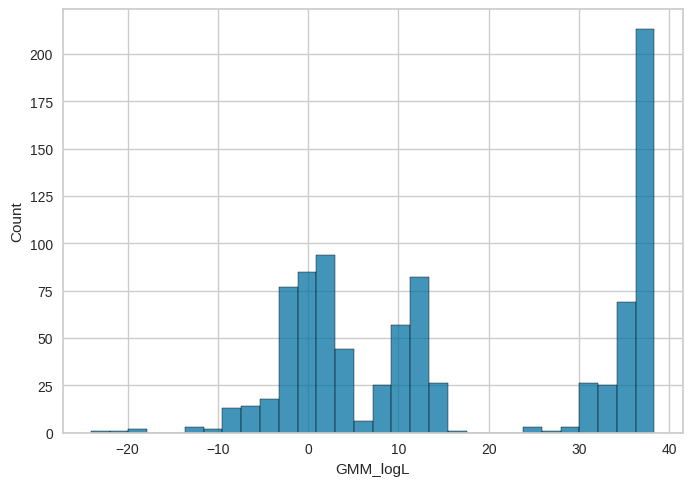

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of hard cluster labels
# sns.countplot(X_train_gmm['GMM_cluster_label'])
# plt.show()

# Distribution of log-likelihoods
sns.histplot(X_train_gmm['GMM_logL'], bins=30)
plt.show()


### row-wise statistical features
This is row-wise feature engineering, often useful when you have many numeric features and want the model to capture overall patterns.

In [3]:
import pandas as pd

def generate_row_stats_features(X_train, X_test, columns=None):
    """
    Generate row-wise statistical features:
    sum, min, max, mean, std, skew, kurtosis, median
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training data
    X_test : pd.DataFrame
        Test data
    columns : list or None
        Columns to use for aggregation; if None, use all columns in X_train
    
    Returns
    -------
    X_train_stats : pd.DataFrame
        Row-wise statistics features for train
    X_test_stats : pd.DataFrame
        Row-wise statistics features for test
    """
    if columns is None:
        columns = X_train.columns.tolist()
    
    X_train_stats = pd.DataFrame(index=X_train.index)
    X_test_stats  = pd.DataFrame(index=X_test.index)
    
    # Define row-wise stats
    stats = {
        'sum': pd.DataFrame.sum,
        'min': pd.DataFrame.min,
        'max': pd.DataFrame.max,
        'mean': pd.DataFrame.mean,
        'std': pd.DataFrame.std,
        'skew': pd.DataFrame.skew,
        'kurt': pd.DataFrame.kurt,
        'med': pd.DataFrame.median
    }
    
    for stat_name, func in stats.items():
        X_train_stats[stat_name] = func(X_train[columns], axis=1)
        X_test_stats[stat_name]  = func(X_test[columns], axis=1)
    
    return X_train_stats, X_test_stats


In [4]:
X_train_stats, X_test_stats = generate_row_stats_features(X_train, X_test, columns=num_cols)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_feature_distribution(X, y, features):
    """
    Plots the distribution of features for two classes in y.
    
    Parameters
    ----------
    X : pd.DataFrame
        Feature DataFrame
    y : pd.Series or array-like
        Target values (binary)
    features : list of str
        Feature columns to plot
    """
    # Ensure y is a Series aligned with X
    if not isinstance(y, pd.Series):
        y = pd.Series(y, index=X.index)
    
    sns.set_style('whitegrid')
    num_features = len(features)
    ncols = 5  # number of subplots per row
    nrows = int(np.ceil(num_features / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows*3))
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        t0 = X.loc[y == 0, feature]
        t1 = X.loc[y == 1, feature]
        
        sns.kdeplot(t0, ax=axes[i], label='target: 0', fill=True, alpha=0.5)
        sns.kdeplot(t1, ax=axes[i], label='target: 1', fill=True, alpha=0.5)
        axes[i].set_title(feature, fontsize=10)
        axes[i].tick_params(axis='x', labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
    
    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()


features = X_train_stats.columns  # your new row-wise stats features
plot_feature_distribution(X_train_stats, y_train['target'], features)


ValueError: Data must be 1-dimensional, got ndarray of shape (891, 1) instead

### interaction features (+-*/)

<mark>It might take time</mark>

This function automatically generates interaction features between numerical columns in a dataset, including **addition, subtraction, multiplication, and division**. Each candidate feature is evaluated using cross-validated ROC AUC with a simple gradient boosting model, and only those features that improve predictive performance and are not highly correlated with existing numeric features are kept.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

def generate_interaction_features(train, test, y_train, cols, best_score=0.5, cv_splits=5):
    """
    Generate interaction features (add, subtract, multiply, divide) between numerical columns
    and keep only those that improve CV ROC AUC and are not too correlated with existing features.

    Only numeric columns are used for correlation checks.

    Parameters
    ----------
    train : pd.DataFrame
        Training data (without target).
    test : pd.DataFrame
        Test data.
    y_train : pd.Series
        Target variable.
    cols : list
        List of numerical columns to consider for interactions.
    best_score : float
        Minimum ROC AUC required to keep a new feature.
    cv_splits : int
        Number of CV folds for evaluation.

    Returns
    -------
    train_new : pd.DataFrame
        Training set with new features added.
    test_new : pd.DataFrame
        Test set with new features added.
    new_cols : list
        List of new column names added.
    """

    train_new = train.copy()
    test_new = test.copy()
    new_cols = []

    skf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    
    for i in tqdm(range(len(cols)), desc="Generating Interaction Features"):
        col1 = cols[i]

        for j in range(i+1, len(cols)):
            col2 = cols[j]
            operations = {
                f"{col1}*{col2}": train[col1] * train[col2],
                f"{col1}/{col2}": train[col1] / (train[col2] + 1e-5),
                f"{col2}/{col1}": train[col2] / (train[col1] + 1e-5),
                f"{col1}-{col2}": train[col1] - train[col2],
                f"{col1}+{col2}": train[col1] + train[col2]
            }

            for name, series in operations.items():
                # Skip constant features
                if series.nunique() <= 1:
                    continue

                # CV evaluation
                X_feature = series.values.reshape(-1,1)
                y_target = y_train.values
                auc_scores = []
                for train_idx, val_idx in skf.split(X_feature, y_target):
                    X_tr, X_val = X_feature[train_idx], X_feature[val_idx]
                    y_tr, y_val = y_target[train_idx], y_target[val_idx]
                    model = HistGradientBoostingClassifier(
                        max_iter=300, learning_rate=0.02, max_depth=6, random_state=42
                    )
                    model.fit(X_tr, y_tr)
                    preds = model.predict_proba(X_val)[:,1]
                    auc_scores.append(roc_auc_score(y_val, preds))
                mean_auc = np.mean(auc_scores)

                # Only check correlation against numeric columns
                numeric_cols = train_new.select_dtypes(include=np.number).columns.tolist()
                if numeric_cols:
                    corr_with_existing = train_new[numeric_cols].corrwith(series)
                    max_corr = corr_with_existing.abs().max()
                else:
                    max_corr = 0

                if mean_auc > best_score and max_corr < 0.9:
                    # Add feature to train/test
                    train_new[name] = series
                    if "*" in name:
                        test_new[name] = test[col1] * test[col2]
                    elif "/" in name:
                        test_new[name] = test[col1] / (test[col2] + 1e-5) if name.startswith(col1) else test[col2] / (test[col1] + 1e-5)
                    elif "+" in name:
                        test_new[name] = test[col1] + test[col2]
                    elif "-" in name:
                        test_new[name] = test[col1] - test[col2] if name.startswith(col1) else test[col2] - test[col1]
                    
                    new_cols.append(name)
                    print(f"Added '{name}' | CV ROC AUC: {mean_auc:.4f} | Max Corr: {max_corr:.4f}")

    return train_new, test_new, new_cols

In [4]:
selected_cols = num_cols


# Use the function
train_interaction, test_interaction, interaction_cols = generate_interaction_features(
    train=X_train,
    test=X_test,
    y_train=y_train,
    cols=selected_cols,
    best_score=0.55,   # only keep features improving ROC AUC over 0.55
    cv_splits=3
)

Generating Interaction Features:   0%|          | 0/14 [00:00<?, ?it/s]

Added 'CreditScore*Age' | CV ROC AUC: 0.7109 | Max Corr: 0.8789
Added 'CreditScore/Age' | CV ROC AUC: 0.7262 | Max Corr: 0.8249


Generating Interaction Features:   7%|▋         | 1/14 [04:30<58:33, 270.28s/it]

Added 'Age/Tenure' | CV ROC AUC: 0.6995 | Max Corr: 0.3078
Added 'Age*NumOfProducts' | CV ROC AUC: 0.7936 | Max Corr: 0.8140
Added 'Age/NumOfProducts' | CV ROC AUC: 0.8426 | Max Corr: 0.8097
Added 'Age*EstimatedSalary' | CV ROC AUC: 0.6186 | Max Corr: 0.8698
Added 'Age/EstimatedSalary' | CV ROC AUC: 0.5990 | Max Corr: 0.0718
Added 'EstimatedSalary/Age' | CV ROC AUC: 0.5988 | Max Corr: 0.8776
Added 'Age/Surname_tfidf_0' | CV ROC AUC: 0.6986 | Max Corr: 0.1614
Added 'Age/Surname_tfidf_1' | CV ROC AUC: 0.6736 | Max Corr: 0.1281
Added 'Age/Surname_tfidf_2' | CV ROC AUC: 0.6777 | Max Corr: 0.1394
Added 'Age/Sur_Geo_Gend_Sal_tfidf_0' | CV ROC AUC: 0.7596 | Max Corr: 0.0226
Added 'Age/Sur_Geo_Gend_Sal_tfidf_1' | CV ROC AUC: 0.7604 | Max Corr: 0.0813
Added 'Age/Sur_Geo_Gend_Sal_tfidf_2' | CV ROC AUC: 0.7600 | Max Corr: 0.3409


Generating Interaction Features:  14%|█▍        | 2/14 [09:38<58:27, 292.31s/it]

...

Generating Interaction Features:  64%|██████▍   | 9/14 [28:21<11:51, 142.32s/it]

Added 'Surname_tfidf_1*Surname_tfidf_2' | CV ROC AUC: 0.5702 | Max Corr: 0.8789
Added 'Surname_tfidf_2/Surname_tfidf_1' | CV ROC AUC: 0.5684 | Max Corr: 0.6106
Added 'Surname_tfidf_1-Surname_tfidf_2' | CV ROC AUC: 0.5717 | Max Corr: 0.7041
Added 'Surname_tfidf_1+Surname_tfidf_2' | CV ROC AUC: 0.5734 | Max Corr: 0.7105


Generating Interaction Features:  71%|███████▏  | 10/14 [30:10<08:48, 132.04s/it]

Added 'Surname_tfidf_2/Sur_Geo_Gend_Sal_tfidf_0' | CV ROC AUC: 0.5697 | Max Corr: 0.8274
Added 'Surname_tfidf_2/Sur_Geo_Gend_Sal_tfidf_1' | CV ROC AUC: 0.5705 | Max Corr: 0.8525


Generating Interaction Features: 100%|██████████| 14/14 [31:56<00:00, 136.92s/it]


### Automatic Interaction Feature Search

Instead of blindly creating thousands of features, we:
1️⃣ Generate candidate interactions
2️⃣ Test them with fast CV
3️⃣ Keep only features that improve AUC


In [20]:
from itertools import combinations
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier


def discover_interactions(train, test, y, num_cols, threshold=0.001):

    new_train = pd.DataFrame(index=train.index)
    new_test = pd.DataFrame(index=test.index)

    new_features = []

    model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Use only numeric columns for base model
    base_X = train[num_cols]

    base_scores = []

    for tr, val in skf.split(base_X, y):

        model.fit(base_X.iloc[tr], y.iloc[tr])
        preds = model.predict_proba(base_X.iloc[val])[:,1]

        base_scores.append(roc_auc_score(y.iloc[val], preds))

    base_auc = np.mean(base_scores)

    print("Base AUC:", base_auc)

    for col1, col2 in combinations(num_cols, 2):

        feature_name = f"{col1}_x_{col2}"

        feature = train[col1] * train[col2]

        X_tmp = pd.concat([base_X, feature], axis=1)

        scores = []

        for tr, val in skf.split(X_tmp, y):

            model.fit(X_tmp.iloc[tr], y.iloc[tr])
            preds = model.predict_proba(X_tmp.iloc[val])[:,1]

            scores.append(roc_auc_score(y.iloc[val], preds))

        new_auc = np.mean(scores)

        if new_auc > base_auc + threshold:

            print(feature_name, "improved:", new_auc)

            new_train[feature_name] = train[col1] * train[col2]
            new_test[feature_name] = test[col1] * test[col2]

            new_features.append(feature_name)

            base_auc = new_auc

    return new_train, new_test, new_features

In [21]:
train_new, test_new, new_feats = discover_interactions(
    train=X_train,
    test=X_test,
    y=y_train,
    num_cols=num_cols
)

[LightGBM] [Info] Number of positive: 23280, number of negative: 86742
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2353
[LightGBM] [Info] Number of data points in the train set: 110022, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.211594 -> initscore=-1.315344
[LightGBM] [Info] Start training from score -1.315344
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

###  interaction features between categorical  (✅)
It converts pairs of categorical features into a single encoded interaction feature.


- Combining two features into one

- Turning that combination into a numeric feature

- Doing it consistently for train and test


<mark>To Improve</mark>
“Target encoding smooths category averages with the global mean; min_samples_leaf is the pivot point where we trust the category mean more than the global mean.”

In [178]:
import pandas as pd
import numpy as np
import time


def generate_cross_features(
    X_train,
    X_test,
    combs,
    use_freq=True,
    use_hash_fallback=True,
    verbose=True
):
    """
    Kaggle-grade cross feature generator (safe + scalable + stacking-ready).
    """

    X_train_cross = pd.DataFrame(index=X_train.index)
    X_test_cross  = pd.DataFrame(index=X_test.index)
    cross_features = []

    start = time.time()

    for n_c, (f1, f2) in enumerate(combs):
        name = f"{f1}_x_{f2}"

        if verbose:
            print(f"{name:60} {n_c+1}/{len(combs)}")

        # =========================
        # 1. Create interaction
        # =========================
        trn = X_train[f1].astype(str) + "_" + X_train[f2].astype(str)
        tst = X_test[f1].astype(str)  + "_" + X_test[f2].astype(str)

        # =========================
        # 2. Frequency encoding (VERY IMPORTANT)
        # =========================
        if use_freq:
            freq = trn.value_counts()

            X_train_cross[name] = trn.map(freq)
            X_test_cross[name]  = tst.map(freq)

            # fill unseen with small value
            fill_val = 1
            X_train_cross[name].fillna(fill_val, inplace=True)
            X_test_cross[name].fillna(fill_val, inplace=True)

        # =========================
        # 3. Hash fallback (optional but powerful)
        # =========================
        elif use_hash_fallback:
            X_train_cross[name] = trn.apply(lambda x: hash(x) % 10**6)
            X_test_cross[name]  = tst.apply(lambda x: hash(x) % 10**6)

        # =========================
        # 4. Optional light normalization
        # =========================
        X_train_cross[name] = np.log1p(X_train_cross[name]).astype(np.float32)
        X_test_cross[name]  = np.log1p(X_test_cross[name]).astype(np.float32)

        cross_features.append(name)

        if verbose:
            print(f"done in {(time.time()-start)/60:.2f} min")

    return X_train_cross, X_test_cross, cross_features

- ✔ Nominal categorical columns
- ✔ ID-like categorical columns (VERY strong use case)
- ✔ Medium/high cardinality features
❌ BAD inputs
- ❌ numeric continuous
- ❌ too unique columns
- ❌ Avoid:✖ numeric × anything
**GOOD for**
- Interaction-heavy problems
- Tree models (THEY love it)

In [ ]:
combs = [
    ("user_id", "product_id"),
    ("user_id", "category"),
    ("city", "device_type"),
    ("category", "device_type")
]

# or automatic 
# from itertools import combinations

# combs = list(combinations(categorical_features, 2))
train_cross, test_cross, cross_features = generate_cross_features(
    X_train,
    X_test,
    combs
)

### Frequency Encoding (✅)

In [18]:
import pandas as pd
import numpy as np
import time


def freq_encoding(cols, train_df, test_df, normalize=True, log_scale=True, verbose=True):
    """
    Kaggle-ready frequency encoding (improved version).
    """

    train_freq = pd.DataFrame(index=train_df.index)
    test_freq  = pd.DataFrame(index=test_df.index)
    freq_features = []

    start = time.time()

    for i, col in enumerate(cols):
        col_freq = col + "_freq"

        if verbose:
            print(
                f"Encoding {col:30} {i+1}/{len(cols)} in {(time.time()-start)/60:.2f} min"
            )

        # frequency
        freq = train_df[col].value_counts()

        if normalize:
            freq = freq / len(train_df)

        if log_scale:
            freq = np.log1p(freq)

        # 👉 clip extreme values (optional)
        freq = freq.clip(lower=0)

        # mapping
        train_freq[col_freq] = train_df[col].map(freq)
        test_freq[col_freq]  = test_df[col].map(freq)

        # fill unseen categories
        fill_value = 0.0

        train_freq[col_freq].fillna(fill_value, inplace=True)
        test_freq[col_freq].fillna(fill_value, inplace=True)

        train_freq[col_freq] = train_freq[col_freq].astype(np.float32)
        test_freq[col_freq]  = test_freq[col_freq].astype(np.float32)

        freq_features.append(col_freq)

    return train_freq, test_freq, freq_features



**❌ BAD inputs:**
- continuous numeric features
- almost unique IDs (like transaction_id)
- already encoded features
- Small datasets
**✅ GOOD for**
- High-cardinality features
- Popularity-based systems
- Fraud / anomaly detection
- categorical features
- ID-like features
- repeated values
- EX: city/user_id/product_id/merchant_id/browser/device_type

**INPUT**

✔ Nominal categorical
✔ ID-like categorical
❌ Ordinal (not needed)
❌ Numeric continuous
❌ Text (raw)

In [19]:
cols_to_encode = nom_cols
X_train_freq_enc, X_test_freq_enc, freq_features = freq_encoding(cols_to_encode, X_train, X_test, normalize=True, log_scale=True, verbose=True)

X_train_freq_enc


Encoding nom_0                          1/5 in 0.00 min
Encoding nom_1                          2/5 in 0.00 min
Encoding nom_2                          3/5 in 0.00 min
Encoding nom_3                          4/5 in 0.00 min
Encoding nom_4                          5/5 in 0.00 min


,nom_0_freq,nom_1_freq,nom_2_freq,nom_3_freq,nom_4_freq
0,0.353800,0.094871,0.142596,0.116128,0.205517
1,0.353800,0.290630,0.093754,0.290486,0.248206
2,0.278051,0.290630,0.290914,0.290486,0.167608
3,0.227117,0.290630,0.142596,0.154011,0.268227
4,0.227117,0.290630,0.290914,0.154011,0.268227
...,...,...,...,...,...
299995,0.227117,0.290630,0.142596,0.095165,0.268227
299996,0.353800,0.290630,0.290914,0.290486,0.248206
299997,0.278051,0.142379,0.113733,0.290486,0.268227
299998,0.353800,0.152999,0.113733,0.113293,0.248206


### Binary Encoding (✅),

- Input: numeric categorical feature (values 0 to n‑1) and converts it into binary representation, creating multiple new columns—one for each binary digit (bit). This allows models to capture categorical information in a numeric, bitwise way.


- best used for categorical features with <mark>moderate-to-high cardinality</mark>.
- beats One-hot in high cardinality features
- <mark>no leakage risk</mark>

Example: user_id with 10,000 unique values.

<mark>“High-cardinality categorical → binary encoding saves columns, keeps info numeric, and works well with trees or linear models.”</mark>

In [23]:
import pandas as pd
import numpy as np

def binary_encoding(cols, train_df, test_df, verbose=True):

    train_bin = pd.DataFrame(index=train_df.index)
    test_bin  = pd.DataFrame(index=test_df.index)
    bin_features = []

    for i, feat in enumerate(cols):

        if verbose:
            print(f"Binary encoding column {i+1}/{len(cols)}: {feat}")

        # =========================================================
        # 1. SAFE ENCODING (TRAIN + TEST TOGETHER)
        # =========================================================
        combined = pd.concat([train_df[feat], test_df[feat]], axis=0)

        encoded, _ = pd.factorize(combined)

        trn_vals = encoded[:len(train_df)]
        tst_vals = encoded[len(train_df):]

        # =========================================================
        # 2. HANDLE MISSING VALUES (-1)
        # =========================================================
        feat_max = encoded.max()

        trn_vals = np.where(trn_vals == -1, feat_max + 1, trn_vals)
        tst_vals = np.where(tst_vals == -1, feat_max + 1, tst_vals)

        # =========================================================
        # 3. DETERMINE NUMBER OF BITS
        # =========================================================
        max_val = max(trn_vals.max(), tst_vals.max())
        max_bin_len = len(format(max_val, "b"))

        # =========================================================
        # 4. CREATE BINARY MAP
        # =========================================================
        bin_map = {
            val: [int(b) for b in format(val, f'0{max_bin_len}b')]
            for val in range(max_val + 1)
        }

        bin_cols = [f"{feat}_bin_{j}" for j in range(max_bin_len)]

        # =========================================================
        # 5. APPLY TRANSFORMATION
        # =========================================================
        train_bin_feat = pd.DataFrame(
            [bin_map[v] for v in trn_vals],
            columns=bin_cols,
            index=train_df.index
        )

        test_bin_feat = pd.DataFrame(
            [bin_map[v] for v in tst_vals],
            columns=bin_cols,
            index=test_df.index
        )

        # =========================================================
        # 6. CONCAT
        # =========================================================
        train_bin = pd.concat([train_bin, train_bin_feat], axis=1)
        test_bin  = pd.concat([test_bin, test_bin_feat], axis=1)

        bin_features.extend(bin_cols)

    return train_bin, test_bin, bin_features

In [24]:
# INPUT:
# Ordinal / label-encoded categorical features ord_1: 0, 1, 2, 3
# Integer categorical features (ID-like categories) e.g city_id: 12, 45, 78, 102
# Binary / low-cardinality encoded categories e.g 0 / 1 / 2 / 3 / 4 (few unique values)
# When categories are ID-like (not semantic)
# ❌ Do NOT pass these: “binary columns = 0/1 features” / Continuous numeric / One-hot encoded / Text
# ❌ not good for low-cardinality -> use One-hot
# ❌ dont use when ordinal meaning matters

cols_to_binary = ord_cols
X_train_bin_enc, X_test_bin_enc, bin_features = binary_encoding(cols_to_binary, X_train, X_test)



X_train_bin_enc.head()


Binary encoding column 1/4: ord_0
Binary encoding column 2/4: ord_1
Binary encoding column 3/4: ord_2
Binary encoding column 4/4: ord_3


,ord_0_bin_0,ord_0_bin_1,ord_1_bin_0,ord_1_bin_1,ord_1_bin_2,ord_2_bin_0,ord_2_bin_1,ord_2_bin_2,ord_3_bin_0,ord_3_bin_1,ord_3_bin_2,ord_3_bin_3
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,1,0,0,0,1
2,0,1,0,0,1,0,1,0,0,0,0,0
3,0,1,0,0,0,0,1,1,0,0,1,0
4,0,1,0,0,0,1,0,0,0,0,0,1



### Encoding Functions (✅)



In [ ]:
import pandas as pd
import numpy as np


# =========================================================
# 1. GROUP AGGREGATION ENCODING (SAFE)
# =========================================================
def encode_ag(
    main_cols,
    uids,
    train_df,
    test_df,
    aggregations=("mean", "std"),
    fillna=True,
    verbose=True
):

    train_df = train_df.copy()
    test_df = test_df.copy()

    features = []

    for main_col in main_cols:
        for uid in uids:
            for agg in aggregations:

                new_col = f"{main_col}_{uid}_{agg}"

                # 🔥 compute ONLY on train (NO leakage)
                stats = train_df.groupby(uid)[main_col].agg(agg)

                train_df[new_col] = train_df[uid].map(stats)
                test_df[new_col]  = test_df[uid].map(stats)

                # fill missing (safe fallback)
                if fillna:
                    fill_value = train_df[new_col].mean()
                    train_df[new_col] = train_df[new_col].fillna(fill_value)
                    test_df[new_col]  = test_df[new_col].fillna(fill_value)

                features.append(new_col)

                if verbose:
                    print(new_col, ", ", end="")

    return train_df[features], test_df[features], features


# =========================================================
# 2. COMBINATION FEATURE GENERATOR (SAFE)
# =========================================================
def encode_cb(
    col1,
    col2,
    train_df,
    test_df,
    encode_func=None,
    verbose=True
):

    train_df = train_df.copy()
    test_df = test_df.copy()

    new_col = f"{col1}_{col2}"

    # create interaction feature
    train_df[new_col] = train_df[col1].astype(str) + "_" + train_df[col2].astype(str)
    test_df[new_col]  = test_df[col1].astype(str) + "_" + test_df[col2].astype(str)

    # optional encoding (SAFE ONLY if encode_func is non-target based)
    if encode_func is not None:
        train_df, test_df, _ = encode_func([new_col], train_df, test_df)

    if verbose:
        print(new_col, ", ", end="")

    return train_df[[new_col]], test_df[[new_col]], [new_col]


# =========================================================
# 3. NUNIQUE GROUP ENCODING (SAFE)
# =========================================================
def encode_ag_nunique(
    main_cols,
    uids,
    train_df,
    test_df,
    fillna=True,
    verbose=True
):

    train_df = train_df.copy()
    test_df = test_df.copy()

    features = []

    for main_col in main_cols:
        for uid in uids:

            new_col = f"{uid}_{main_col}_nunique"

            # compute from TRAIN only (NO leakage)
            stats = train_df.groupby(uid)[main_col].nunique()

            train_df[new_col] = train_df[uid].map(stats)
            test_df[new_col]  = test_df[uid].map(stats)

            # handle missing safely
            if fillna:
                train_df[new_col] = train_df[new_col].fillna(0)
                test_df[new_col]  = test_df[new_col].fillna(0)

            features.append(new_col)

            if verbose:
                print(new_col, ", ", end="")

    return train_df[features], test_df[features], features

**Group aggregations**

It creates statistics of a numeric column grouped by a category.

- main_cols → numeric columns (target-like or continuous)
- uids      → ✔ Nominal categorical/✔ ID-like categorical/ categorical grouping columns

**When it is GOOD**
- User behavior problems:  user_id
- Fraud detection: merchant_id
❌ When it is BAD
- very small datasets
- when group size is 1 (no signal)
- noisy IDs with no repetition

In [ ]:
# Example columns
main_cols = ["target_col"]          # numeric / target-related features
uids = ["user_id", "product_id"]    # categorical group keys

train_ag, test_ag, ag_features = encode_ag(
    main_cols=main_cols,
    uids=uids,
    train_df=X_train,
    test_df=X_test,
    aggregations=["mean", "std"]
)

**Nunique features**

“How many unique values exist per group?”
- main_cols → categorical or interaction target column
- - ✔ Nominal categorical
- - ✔ event-type categorical
- uids      → grouping columns
- - ✔ ID-like categorical

In [ ]:
main_cols = ["product_id"]
uids = ["user_id"]

train_nu, test_nu, nu_features = encode_ag_nunique(
    main_cols=["target_col"],
    uids=uids,
    train_df=X_train,
    test_df=X_test
)

**Combine features**

It creates interaction features:

- user_id + product_id → "user123_product45"

✅ When it is GOOD
- Interaction problems: user-product behavior
- CTR prediction: ad × user interactions

❌ When it is BAD
- both columns have too many unique values → explosion
- no repetition (almost all unique pairs)


**INPUT**: ✔ Nominal categorical ✔ ID-like categorical ✔ medium/high cardinality features

In [ ]:
train_cb, test_cb, cb_features = encode_cb(
    col1="user_id",
    col2="product_id",
    train_df=X_train,
    test_df=X_test
)

### **Target Encoding** (✅)

Smoothing is computed like in the following paper by Daniele Micci-Barreca
https://kaggle2.blob.core.windows.net/forum-message-attachments/225952/7441/high%20cardinality%20categoricals.pdf
trn_series : training categorical feature as a pd.Series
tst_series : test categorical feature as a pd.Series
target : target data as a pd.Series
min_samples_leaf (int) : minimum samples to take category average into account
smoothing (int) : smoothing effect to balance categorical average vs prior

In [28]:
import pandas as pd
import numpy as np


def add_noise(series, noise_level=0):
    if noise_level > 0:
        return series * (1 + noise_level * np.random.randn(len(series)))
    return series


def target_encode_cols_oof(
    cols,
    X_train,
    X_test,
    y_train,
    folds,                  # 🔥 YOUR FOLDS HERE
    min_samples_leaf=1,
    smoothing=1,
    noise_level=0,
    verbose=True
):

    y_train = pd.Series(y_train).reset_index(drop=True)
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)

    train_enc = pd.DataFrame(index=X_train.index)
    test_enc  = pd.DataFrame(index=X_test.index)
    enc_features = []

    global_mean = y_train.mean()

    for i, col in enumerate(cols):

        if verbose:
            print(f"OOF Target encoding: {col} ({i+1}/{len(cols)})")

        oof = np.zeros(len(X_train))
        test_folds = np.zeros((len(folds), len(X_test)))

        # =====================================================
        # 🔥 OOF USING YOUR PREDEFINED FOLDS
        # =====================================================
        for fold_id, (tr_idx, val_idx) in enumerate(folds):

            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr = y_train.iloc[tr_idx]

            stats = pd.concat([X_tr[col], y_tr], axis=1)
            agg = stats.groupby(col)[y_train.name].agg(["mean", "count"])

            # smoothing
            smooth = 1 / (1 + np.exp(-(agg["count"] - min_samples_leaf) / smoothing))
            enc_map = global_mean * (1 - smooth) + agg["mean"] * smooth

            # OOF
            oof[val_idx] = X_val[col].map(enc_map).fillna(global_mean)

            # test fold
            test_folds[fold_id] = X_test[col].map(enc_map).fillna(global_mean)

        # final outputs
        train_enc[col + "_te_oof"] = add_noise(pd.Series(oof), noise_level)
        test_enc[col + "_te_oof"]  = add_noise(pd.Series(test_folds.mean(axis=0)), noise_level)

        enc_features.append(col + "_te_oof")

    return train_enc, test_enc, enc_features

- Medium / high-cardinality categorical features. Example
- - user_id
- - product_id
- - city
- - merchant_id
- When category → strong signal effect target

Works extremely well with:
- LightGBM
- XGBoost

- ❌ dont use for Small datasets
- ❌ Low-cardinality features
- ❌ Do NOT pass: Continuous features/Continuous features/IDs with NO repetition

In [32]:
categorical_cols = high_card_feats

X_train_cat_te_oof, X_test_cat_te_oof, new_features_te = target_encode_cols_oof(
    cols=categorical_cols,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train[TARGET],
    folds=folds,
    min_samples_leaf=5, # Hyperparam: 1
    smoothing=10, # Hyperparam: 1
    noise_level=0.01, # Hyperparam: 0
    verbose=True
)

# Append new features to original datasets

X_train_cat_te_oof.head()

OOF Target encoding: nom_5 (1/5)
OOF Target encoding: nom_6 (2/5)
OOF Target encoding: nom_7 (3/5)
OOF Target encoding: nom_8 (4/5)
OOF Target encoding: nom_9 (5/5)


,nom_5_te_oof,nom_6_te_oof,nom_7_te_oof,nom_8_te_oof,nom_9_te_oof
0,0.355138,0.313166,0.220459,0.365630,0.379366
1,0.392477,0.269334,0.322363,0.194784,0.178740
2,0.272840,0.294233,0.198024,0.217449,0.231669
3,0.245417,0.361755,0.347587,0.331737,0.201513
4,0.313744,0.306137,0.266654,0.405731,0.248308


### CatBoostEncoder (✅)

In [35]:
import numpy as np
import pandas as pd
from category_encoders import CatBoostEncoder


def catboost_encode_oof(
    cols,
    X_train,
    X_test,
    y_train,
    folds,
    verbose=True
):
    """
    Leakage-safe CatBoost encoding using external folds (OOF style).
    Compatible with stacking pipelines.
    """

    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = pd.Series(y_train).reset_index(drop=True)

    train_enc = pd.DataFrame(index=X_train.index)
    test_enc = pd.DataFrame(index=X_test.index)

    feature_names = []

    for col in cols:

        if verbose:
            print(f"Encoding {col}...")

        oof_train = np.zeros(len(X_train))
        test_folds = np.zeros((len(folds), len(X_test)))

        # =========================
        # OOF encoding using YOUR folds
        # =========================
        for i, (tr_idx, val_idx) in enumerate(folds):

            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr = y_train.iloc[tr_idx]

            encoder = CatBoostEncoder(cols=[col])

            encoder.fit(X_tr[[col]], y_tr)

            oof_train[val_idx] = encoder.transform(X_val[[col]]).values.ravel()
            test_folds[i] = encoder.transform(X_test[[col]]).values.ravel()

        # final features
        train_enc[f"{col}_catb_oof"] = oof_train
        test_enc[f"{col}_catb_oof"] = test_folds.mean(axis=0)

        feature_names.append(f"{col}_catb_oof")

    return train_enc, test_enc, feature_names

**Good for**
- Large datasets
- Strong category → target relationship
- Tree models
- ❌ not good for Small datasets
- ❌ Low-cardinality features
- ❌ random category unrelated to target
**INPUT**
- Categorical columns (string or label-encoded)
- - city: "Paris", "London", "NY"
- - product_id: 1, 2, 3, 10
- - category: A, B, C
- Medium → high cardinality: Rule of thumb:
- - n_unique > 10 → good
- - n_unique > 50 → very good
- Repeated categories (VERY IMPORTANT)
- - A appears 1000 times → GOOD
- - A appears once → BAD
- ❌ Continuous numeric features
- ❌ Columns with almost all unique values

In [37]:
X_train_catb_enc, X_test_catb_enc, catb_features = catboost_encode_oof(high_card_feats, X_train, X_test, y_train[TARGET], folds)

X_train_catb_enc


Encoding nom_5...
Encoding nom_6...
Encoding nom_7...
Encoding nom_8...
Encoding nom_9...


,nom_5_catb_oof,nom_6_catb_oof,nom_7_catb_oof,nom_8_catb_oof,nom_9_catb_oof
0,0.354940,0.311752,0.220887,0.368376,0.384520
1,0.392945,0.271823,0.324815,0.196658,0.118717
2,0.276652,0.298235,0.197684,0.216999,0.221078
3,0.245624,0.358455,0.349878,0.333158,0.202941
4,0.317127,0.303555,0.268467,0.400612,0.242534
...,...,...,...,...,...
299995,0.328226,0.222828,0.316221,0.273702,0.341176
299996,0.360215,0.415226,0.230293,0.290422,0.171157
299997,0.350109,0.343008,0.290422,0.330376,0.315294
299998,0.290851,0.278163,0.383619,0.288643,0.361125


Advanced Custom Version use it if u want to squeeze kaggle leaderboard
<mark>leakage use folds</mark>

In [ ]:
import pandas as pd
import numpy as np


def add_noise(series, noise_level=0):
    if noise_level > 0:
        return series * (1 + noise_level * np.random.randn(len(series)))
    return series


def catboost_encode_custom(
    cols,
    X_train,
    X_test,
    y_train,
    n_perm=3,
    smoothing=10,
    noise_level=0,
    random_state=42,
    verbose=True
):
    """
    Advanced CatBoost-style encoding with multiple permutations + smoothing.

    Returns:
        train_enc, test_enc, feature_names
    """

    np.random.seed(random_state)
    y_train = y_train.squeeze()

    train_enc = pd.DataFrame(index=X_train.index)
    test_enc  = pd.DataFrame(index=X_test.index)
    enc_features = []

    global_mean = y_train.mean()

    for i, col in enumerate(cols):
        if verbose:
            print(f"Custom CatBoost encoding {i+1}/{len(cols)}: {col}")

        col_encoded = np.zeros(len(X_train))

        # --- multiple permutations ---
        for _ in range(n_perm):
            perm = np.random.permutation(len(X_train))
            X_perm = X_train.iloc[perm]
            y_perm = y_train.iloc[perm]

            cumsum = y_perm.groupby(X_perm[col]).cumsum() - y_perm
            cumcnt = X_perm.groupby(col).cumcount()

            # 🔥 smoothing added
            smooth = 1 / (1 + np.exp(-(cumcnt) / smoothing))
            encoded = global_mean * (1 - smooth) + (cumsum / (cumcnt + 1)) * smooth

            encoded = pd.Series(encoded.values, index=X_perm.index)
            encoded = encoded.sort_index()

            col_encoded += encoded.values

        col_encoded /= n_perm

        train_enc[col + "_cb_custom"] = add_noise(pd.Series(col_encoded, index=X_train.index), noise_level)

        # --- test encoding ---
        temp = pd.concat([X_train[col], y_train], axis=1)
        averages = temp.groupby(col)[y_train.name].mean()

        test_col = X_test[col].map(averages)
        test_col.fillna(global_mean, inplace=True)

        test_enc[col + "_catb_custom"] = add_noise(test_col, noise_level)

        enc_features.append(col + "_catb_custom")

    return train_enc, test_enc, enc_features

In [ ]:
train_catb_cus, test_catb_cus, f2 = catboost_encode_custom(high_card_feats,
                                                          X_train,
                                                          X_test,
                                                          y_train[TARGET],
                                                          folds=folds,
                                                          smoothing=10,
                                                          noise_level=0,
                                                          )

train_catb_cus.head()

Custom CatBoost encoding 1/5: nom_5
Custom CatBoost encoding 2/5: nom_6
Custom CatBoost encoding 3/5: nom_7
Custom CatBoost encoding 4/5: nom_8
Custom CatBoost encoding 5/5: nom_9


,nom_5_cb_custom,nom_6_cb_custom,nom_7_cb_custom,nom_8_cb_custom,nom_9_cb_custom
0,0.370549,0.311455,0.239417,0.364047,0.195577
1,0.373486,0.255076,0.300430,0.252226,0.201366
2,0.279981,0.293098,0.207307,0.202502,0.145111
3,0.214029,0.365202,0.351200,0.316066,0.187004
4,0.308442,0.291488,0.270634,0.399924,0.214318


### MEstimateEncoder (✅)

In [38]:
import numpy as np
import pandas as pd


def add_noise(series, noise_level=0):
    if noise_level > 0:
        return series * (1 + noise_level * np.random.randn(len(series)))
    return series


def m_estimate_oof_encode(
    cols,
    X_train,
    X_test,
    y_train,
    folds,
    m=10,
    noise_level=0,
    verbose=True
):
    """
    STACKING-SAFE M-Estimate encoding using PREDEFINED folds (no leakage).
    """

    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = pd.Series(y_train).reset_index(drop=True)

    global_mean = y_train.mean()

    train_enc = pd.DataFrame(index=X_train.index)
    test_enc = pd.DataFrame(index=X_test.index)
    features = []

    for col in cols:

        if verbose:
            print(f"OOF M-Estimate encoding: {col}")

        oof = np.zeros(len(X_train))
        test_folds = np.zeros((len(folds), len(X_test)))

        # =========================
        # OOF USING YOUR FOLDS
        # =========================
        for i, (tr_idx, val_idx) in enumerate(folds):

            X_tr = X_train.iloc[tr_idx]
            X_val = X_train.iloc[val_idx]
            y_tr = y_train.iloc[tr_idx]

            temp = pd.concat([X_tr[col], y_tr], axis=1)
            stats = temp.groupby(col)[y_train.name].agg(["sum", "count"])

            enc_map = (stats["sum"] + m * global_mean) / (stats["count"] + m)

            oof[val_idx] = X_val[col].map(enc_map).fillna(global_mean)
            test_folds[i] = X_test[col].map(enc_map).fillna(global_mean)

        train_enc[f"{col}_m_est_oof"] = add_noise(oof, noise_level)
        test_enc[f"{col}_m_est_oof"] = test_folds.mean(axis=0)

        features.append(f"{col}_m_est_oof")

    return train_enc, test_enc, features

**INPUT**
- Categorical features
- - city/country/category/product_type
- ID-like categorical features
- - user_id/product_id
- ✔ high cardinality
- ✔ repeated values
- Medium cardinality features
- - zip_code/device_type
- ❌ Continuous numeric features
- ❌ Almost unique IDs

- ❌ BAD CASES
- ❌ small dataset (< 2k rows)
- ❌ low-cardinality features
- ❌ time series (without special handling)

In [40]:
X_train_m_estimate_oof, X_test_m_estimate_oof, m_estimate_features = m_estimate_oof_encode(
    high_card_feats,
    X_train,
    X_test,
    y_train[TARGET],
    folds=folds,
    m=10,
    noise_level=0,
    verbose=True
)

X_train_m_estimate_oof

OOF M-Estimate encoding: nom_5
OOF M-Estimate encoding: nom_6
OOF M-Estimate encoding: nom_7
OOF M-Estimate encoding: nom_8
OOF M-Estimate encoding: nom_9


,nom_5_m_est_oof,nom_6_m_est_oof,nom_7_m_est_oof,nom_8_m_est_oof,nom_9_m_est_oof
0,0.354727,0.311696,0.224790,0.365898,0.359243
1,0.391732,0.272276,0.324125,0.206792,0.202940
2,0.276780,0.298306,0.200149,0.220523,0.244206
3,0.246305,0.357957,0.348808,0.331680,0.223529
4,0.317064,0.303577,0.269392,0.395927,0.258823
...,...,...,...,...,...
299995,0.328104,0.223676,0.315359,0.280437,0.334558
299996,0.359990,0.414128,0.232318,0.291265,0.201470
299997,0.349899,0.342637,0.291265,0.328693,0.312372
299998,0.290934,0.281205,0.375668,0.289378,0.345587


### **feature hashing** (✅)

- You have very high-cardinality categorical data (e.g., user IDs, words, URLs)
- You need fast + memory-efficient preprocessing
- You are using linear models (LogReg, SGD, linear SVM)

In [41]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction import FeatureHasher

def feature_hashing(X_train, X_test, cols, n_features=64):

    hasher = FeatureHasher(
        n_features=n_features,
        input_type="dict",
        alternate_sign=True
    )

    train_dicts = X_train[cols].astype(str).apply(
        lambda row: {f"{c}_{row[c]}": 1 for c in cols},
        axis=1
    )

    test_dicts = X_test[cols].astype(str).apply(
        lambda row: {f"{c}_{row[c]}": 1 for c in cols},
        axis=1
    )

    X_tr_hash = hasher.transform(train_dicts).toarray()
    X_te_hash = hasher.transform(test_dicts).toarray()

    hash_cols = [f"hash_{i}" for i in range(n_features)]

    train_hash_df = pd.DataFrame(X_tr_hash, columns=hash_cols, index=X_train.index)
    test_hash_df = pd.DataFrame(X_te_hash, columns=hash_cols, index=X_test.index)

    return train_hash_df, test_hash_df, hash_cols

**INPUT**
- high-cardinality categorical features exist

In [42]:
high_card_feats = high_card_feats

X_train_hash_enc, X_test_hash_enc, hash_feature_names = feature_hashing(
    X_train,
    X_test,
    high_card_feats,
    n_features=64 # = sqrt(total_unique_categories) use 64 – 128 or or small data 32 – 64
)

X_train_hash_enc.head()

,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,...,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63
0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,-1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,-1.0,1.0,0.0
4,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



#### Categorical Feature Encoding Pipeline (✅)
The goal is to convert categorical variables into numerical representations while automatically selecting the most useful encoding strategy.





In [27]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier
from joblib import Parallel, delayed


# =========================================================
# FEATURE ENGINEERING ENGINE
# =========================================================
class FeatureFactory:
    def __init__(self, n_splits=5, smoothing=20, n_jobs=-1):
        self.n_splits = n_splits
        self.smoothing = smoothing
        self.n_jobs = n_jobs

        self.te_maps = {}
        self.global_means = {}  # FIX 1: per-column global mean storage

    # -----------------------------------------------------
    # Target encoding map
    # -----------------------------------------------------
    def _get_te_map(self, X, y, col):
# Ensure y is a Series for grouping
        y_ser = y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y
        global_mean = y_ser.mean()

        stats = y_ser.groupby(X[col]).agg(["mean", "count"])
        
        # FIX: Robust column access
        counts = stats.get("count")
        means = stats.get("mean")

        smooth = counts / (counts + self.smoothing)
        return global_mean * (1 - smooth) + means * smooth

    # -----------------------------------------------------
    # OOF target encoding (NO LEAKAGE)
    # -----------------------------------------------------
    def fit_transform_te(self, X, y, col):
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)

        oof = np.zeros(len(X))

        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=42)

        for tr_idx, val_idx in kf.split(X):
            X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]

            enc_map = self._get_te_map(X_tr, y_tr, col)

            global_mean = y_tr.mean()
            self.global_means[col] = global_mean  # FIX 1

            oof[val_idx] = (
                X.iloc[val_idx][col]
                .map(enc_map)
                .fillna(global_mean)
            )

        # final map for test
        self.te_maps[col] = self._get_te_map(X, y, col)

        return oof

    # -----------------------------------------------------
    # SAFE transform for test
    # -----------------------------------------------------
    def transform_te(self, X, col):
        global_mean = self.global_means[col]  # FIX 1

        return (
            X[col]
            .map(self.te_maps[col])
            .fillna(global_mean)
        )

    # -----------------------------------------------------
    # feature scoring
    # -----------------------------------------------------
    def score_single_feature(self, X_col, y):
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=42)

        scores = []

        for tr, val in kf.split(X_col):
            model = HistGradientBoostingClassifier(
                max_iter=150,
                max_depth=5,
                random_state=42
            )

            model.fit(X_col[tr], y[tr])
            preds = model.predict_proba(X_col[val])[:, 1]

            scores.append(roc_auc_score(y[val], preds))

        return np.mean(scores)

    def fast_score_features(self, X, y, features):
        y = y.values.ravel()

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self.score_single_feature)(X[[col]].values, y)
            for col in features
        )

        return dict(zip(features, results))

    # -----------------------------------------------------
    # SAFE division (FIX 3)
    # -----------------------------------------------------
    def safe_div(self, a, b):
        a = np.clip(a, -1e6, 1e6)
        b = np.clip(b, -1e6, 1e6)

        return np.nan_to_num(
            a / (b + 1e-9),
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

    # -----------------------------------------------------
    # feature generation
    # -----------------------------------------------------
    def add_advanced_features(self, X_tr, X_te, cat_cols, num_cols):

        # -------------------------
        # categorical features
        # -------------------------
        for col in cat_cols:
            freq = X_tr[col].value_counts()
            rank_map = {k: i for i, k in enumerate(freq.index)}

            X_tr[f"{col}_cnt"] = X_tr[col].map(freq).fillna(0)
            X_te[f"{col}_cnt"] = X_te[col].map(freq).fillna(0)

            X_tr[f"{col}_rnk"] = X_tr[col].map(rank_map).fillna(-1)
            X_te[f"{col}_rnk"] = X_te[col].map(rank_map).fillna(-1)

        # -------------------------
        # numeric interactions
        # -------------------------
        top_n = min(len(num_cols), 5)

        for i in range(top_n):
            for j in range(i + 1, top_n):
                c1, c2 = num_cols[i], num_cols[j]

                X_tr[f"{c1}_div_{c2}"] = self.safe_div(X_tr[c1], X_tr[c2])
                X_te[f"{c1}_div_{c2}"] = self.safe_div(X_te[c1], X_te[c2])

        return X_tr, X_te


# =========================================================
# FULL PIPELINE (KAGGLE SAFE)
# =========================================================
def run_advanced_pipeline(X_train, X_test, y_train, cat_cols, num_cols, top_k=15):

    factory = FeatureFactory(n_jobs=-1)

    # 1. base features
    X_tr, X_te = factory.add_advanced_features(
        X_train.copy(),
        X_test.copy(),
        cat_cols,
        num_cols
    )

    # 2. target encoding
    for col in cat_cols:
        X_tr[f"{col}_te"] = factory.fit_transform_te(X_tr, y_train, col)
        X_te[f"{col}_te"] = factory.transform_te(X_te, col)

    # =====================================================
    # FIX 2: SAFE COLUMN ALIGNMENT (ORDER PRESERVED)
    # =====================================================
    common_cols = [c for c in X_tr.columns if c in X_te.columns]

    X_tr = X_tr[common_cols]
    X_te = X_te[common_cols]

    # 3. engineered features only
    engineered = [c for c in X_tr.columns if c not in X_train.columns]

    # 4. scoring
    scores = factory.fast_score_features(X_tr, y_train, engineered)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    selected = [f for f, _ in ranked[:top_k]]

    print("\n🔥 TOP FEATURES:")
    for f, s in ranked[:5]:
        print(f"{f}: {s:.5f}")

    return X_tr[selected], X_te[selected], scores

**INPUTS**
- Nominal categorical features (MAIN INPUT)
- Ordinal features (ONLY IF treated as categorical)
- ❌ Ordinal features ✔ If truly ordered → DO NOT use this pipeline

In [28]:
cat_cols = nom_cols
num_cols = num_cols

X_train_final, X_test_final, scores = run_advanced_pipeline(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    cat_cols=cat_cols,
    num_cols=num_cols,
    top_k=20
)


🔥 TOP FEATURES:
nom_0_cnt: 0.55447
nom_0_rnk: 0.55447
nom_0_te: 0.55447
nom_4_cnt: 0.55103
nom_4_rnk: 0.55103


### Log Features and Squares (✅),

better for regression tasks: 

In [ ]:
import numpy as np
import pandas as pd


# =========================================================
# LOG FEATURES
# =========================================================
def add_log_features(X_train, X_test, cols):
    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in cols:
        if col in X_train.columns and col in X_test.columns:
            X_train[f"{col}_log"] = np.log1p(X_train[col])
            X_test[f"{col}_log"] = np.log1p(X_test[col])

    return X_train, X_test


# =========================================================
# SQUARED FEATURES
# =========================================================
def add_square_features(X_train, X_test, cols):
    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in cols:
        if col in X_train.columns and col in X_test.columns:
            X_train[f"{col}_sq"] = X_train[col] ** 2
            X_test[f"{col}_sq"] = X_test[col] ** 2

    return X_train, X_test

In [ ]:
# log_features = [
#     'LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2',
#     'BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF',
#     'GrLivArea','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath',
#     'BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces',
#     'GarageCars','GarageArea','WoodDeckSF','OpenPorchSF',
#     'EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea','MiscVal',
#     'YearRemodAdd','TotalBsmtSF'
# ]

# squared_features = [
#     'YearRemodAdd', 'LotFrontage_log',
#     'TotalBsmtSF_log', '1stFlrSF_log', '2ndFlrSF_log',
#     'GrLivArea_log', 'GarageCars_log', 'GarageArea_log'
# ]


# # APPLY
# all_features = add_log_features(X_train, X_test,  log_features)
# all_features = add_square_features(X_train, X_test,  squared_features)

### **Encoding cyclic features** (✅)

A common method for encoding cyclical data is to transform the data into two dimensions using a sine and consine transformation.

In [44]:
import numpy as np
import pandas as pd

class AdvancedCyclicEncoder:
    def __init__(self):
        self.periods = {}

    def fit(self, X, cols, period_map=None):
        self.periods = {}

        for col in cols:
            if period_map and col in period_map:
                self.periods[col] = period_map[col]
            else:
                self.periods[col] = int(X[col].max()) + 1

        return self

    def transform(self, X, cols):
        X = X.copy()

        out = {}

        for col in cols:
            period = self.periods[col]
            if period <= 1:
                period = 1

            angle = 2 * np.pi * X[col] / period

            out[f"{col}_sin"] = np.sin(angle)
            out[f"{col}_cos"] = np.cos(angle)

        return pd.DataFrame(out, index=X.index)

    def fit_transform(self, X, cols, period_map=None):
        self.fit(X, cols, period_map)
        return self.transform(X, cols)

In [45]:
data_cols = ["day", "month"]

encoder = AdvancedCyclicEncoder()

train_cyclic = encoder.fit_transform(
    X_train,
    data_cols,
    period_map={"day": 7, "month": 12}
)

test_cyclic = encoder.transform(X_test, data_cols)

train_cyclic

,day_sin,day_cos,month_sin,month_cos
0,9.749279e-01,-0.222521,0.866025,5.000000e-01
1,-2.449294e-16,1.000000,-0.866025,-5.000000e-01
2,-2.449294e-16,1.000000,0.866025,5.000000e-01
3,9.749279e-01,-0.222521,0.500000,8.660254e-01
4,-2.449294e-16,1.000000,-0.866025,-5.000000e-01
...,...,...,...,...
299995,4.338837e-01,-0.900969,-0.866025,-5.000000e-01
299996,4.338837e-01,-0.900969,0.866025,5.000000e-01
299997,-2.449294e-16,1.000000,-1.000000,-1.836970e-16
299998,4.338837e-01,-0.900969,-0.866025,-5.000000e-01


### concatenate everhitng


In [46]:
def safe_concat(*dfs):
    cleaned = [
        df for df in dfs
        if isinstance(df, pd.DataFrame) and not df.empty
    ]

    if not cleaned:
        return pd.DataFrame()

    return pd.concat(cleaned, axis=1, copy=False)

X_train_engineered = safe_concat(
    X_train_cat_features,
    X_train_freq_enc,
    X_train_bin_enc,
    X_train_cat_te_oof,
    X_train_catb_enc,
    X_train_m_estimate_oof,
    X_train_hash_enc,
    train_cyclic
)

X_test_engineered = safe_concat(
    X_test_cat_features,
    X_test_freq_enc,
    X_test_bin_enc,
    X_test_cat_te_oof,
    X_test_catb_enc,
    X_test_m_estimate_oof,
    X_test_hash_enc,
    test_cyclic
)
print("X_train_engineered shape: ", X_train_engineered.shape)
print("X_test_engineered shape: ", X_test_engineered.shape)

X_train_engineered

X_train_engineered shape:  (300000, 130)
X_test_engineered shape:  (200000, 130)


,nom_0_te,nom_0_woe,nom_0_cnt,nom_0_freq,nom_0_std,nom_0_cluster,nom_1_te,nom_1_woe,nom_1_cnt,nom_1_freq,...,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,day_sin,day_cos,month_sin,month_cos
0,0.326272,0.098327,127341,11.754632,0.469173,0,0.359270,0.248330,29855,10.304141,...,0.0,-1.0,0.0,0.0,0.0,-1.0,9.749279e-01,-0.222521,0.866025,5.000000e-01
1,0.326749,0.098327,127341,11.754632,0.469173,0,0.289959,-0.075668,101181,11.524676,...,0.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-0.866025,-5.000000e-01
2,0.242844,-0.323438,96166,11.473842,0.428170,2,0.290362,-0.075668,101181,11.524676,...,1.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,0.866025,5.000000e-01
3,0.351104,0.205033,76493,11.244967,0.477302,1,0.290362,-0.075668,101181,11.524676,...,0.0,0.0,0.0,-1.0,1.0,0.0,9.749279e-01,-0.222521,0.500000,8.660254e-01
4,0.351118,0.205033,76493,11.244967,0.477302,1,0.289959,-0.075668,101181,11.524676,...,0.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-0.866025,-5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,0.350857,0.205033,76493,11.244967,0.477302,1,0.289758,-0.075668,101181,11.524676,...,0.0,0.0,0.0,0.0,0.0,0.0,4.338837e-01,-0.900969,-0.866025,-5.000000e-01
299996,0.327524,0.098327,127341,11.754632,0.469173,0,0.289758,-0.075668,101181,11.524676,...,0.0,0.0,0.0,0.0,0.0,0.0,4.338837e-01,-0.900969,0.866025,5.000000e-01
299997,0.240977,-0.323438,96166,11.473842,0.428170,2,0.311425,0.022260,45904,10.734329,...,0.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-1.000000,-1.836970e-16
299998,0.326749,0.098327,127341,11.754632,0.469173,0,0.340056,0.151394,49597,10.811706,...,1.0,0.0,0.0,0.0,0.0,0.0,4.338837e-01,-0.900969,-0.866025,-5.000000e-01


❌ remove features that have zero variance

In [47]:
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

vt = VarianceThreshold(threshold=0.001)

X_train_np = vt.fit_transform(X_train_engineered)
X_test_np  = vt.transform(X_test_engineered)

# keep only selected columns
kept_cols = X_train_engineered.columns[vt.get_support()]

X_train_engineered = pd.DataFrame(X_train_np, columns=kept_cols, index=X_train_engineered.index)
X_test_engineered  = pd.DataFrame(X_test_np, columns=kept_cols, index=X_test_engineered.index)

In [48]:
X_train_engineered

,nom_0_te,nom_0_woe,nom_0_cnt,nom_0_freq,nom_0_cluster,nom_1_te,nom_1_woe,nom_1_cnt,nom_1_freq,nom_1_cluster,...,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,day_sin,day_cos,month_sin,month_cos
0,0.326272,0.098327,127341.0,11.754632,0.0,0.359270,0.248330,29855.0,10.304141,2.0,...,0.0,-1.0,0.0,0.0,0.0,-1.0,9.749279e-01,-0.222521,0.866025,5.000000e-01
1,0.326749,0.098327,127341.0,11.754632,0.0,0.289959,-0.075668,101181.0,11.524676,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-0.866025,-5.000000e-01
2,0.242844,-0.323438,96166.0,11.473842,2.0,0.290362,-0.075668,101181.0,11.524676,3.0,...,1.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,0.866025,5.000000e-01
3,0.351104,0.205033,76493.0,11.244967,1.0,0.290362,-0.075668,101181.0,11.524676,3.0,...,0.0,0.0,0.0,-1.0,1.0,0.0,9.749279e-01,-0.222521,0.500000,8.660254e-01
4,0.351118,0.205033,76493.0,11.244967,1.0,0.289959,-0.075668,101181.0,11.524676,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-0.866025,-5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,0.350857,0.205033,76493.0,11.244967,1.0,0.289758,-0.075668,101181.0,11.524676,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.338837e-01,-0.900969,-0.866025,-5.000000e-01
299996,0.327524,0.098327,127341.0,11.754632,0.0,0.289758,-0.075668,101181.0,11.524676,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.338837e-01,-0.900969,0.866025,5.000000e-01
299997,0.240977,-0.323438,96166.0,11.473842,2.0,0.311425,0.022260,45904.0,10.734329,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-1.000000,-1.836970e-16
299998,0.326749,0.098327,127341.0,11.754632,0.0,0.340056,0.151394,49597.0,10.811706,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,4.338837e-01,-0.900969,-0.866025,-5.000000e-01


In [49]:
X_train_all = pd.concat(
    [X_train.copy(), X_train_engineered.copy()],
    axis=1
)
X_test_all  = pd.concat(
    [X_test.copy(), X_test_engineered.copy()],
    axis=1
)

**check similar column names** and change them to v1, v2

In [50]:
import pandas as pd

def rename_duplicate_columns(train, test, verbose=True):
    train = train.copy()
    test = test.copy()

    seen = {}
    new_cols = []

    for col in train.columns:
        if col not in seen:
            seen[col] = 0
            new_cols.append(col)
        else:
            seen[col] += 1
            new_name = f"{col}_v{seen[col]}"
            new_cols.append(new_name)

            if verbose:
                print(f"🔁 Renaming: {col} → {new_name}")

    # apply ONLY to train
    train.columns = new_cols

    # now align test safely
    # (IMPORTANT: assumes same original column order)
    test_cols = []
    temp_seen = {}

    for col in test.columns:
        if col not in temp_seen:
            temp_seen[col] = 0
            test_cols.append(col)
        else:
            temp_seen[col] += 1
            test_cols.append(f"{col}_v{temp_seen[col]}")

    test.columns = test_cols

    return train, test

In [51]:
X_train_all, X_test_all = rename_duplicate_columns(X_train_all, X_test_all)

🔁 Renaming: nom_0_freq → nom_0_freq_v1
🔁 Renaming: nom_1_freq → nom_1_freq_v1
🔁 Renaming: nom_2_freq → nom_2_freq_v1
🔁 Renaming: nom_3_freq → nom_3_freq_v1
🔁 Renaming: nom_4_freq → nom_4_freq_v1


In [52]:
X_train_engineered, X_test_engineered = rename_duplicate_columns(X_train_engineered, X_test_engineered)

🔁 Renaming: nom_0_freq → nom_0_freq_v1
🔁 Renaming: nom_1_freq → nom_1_freq_v1
🔁 Renaming: nom_2_freq → nom_2_freq_v1
🔁 Renaming: nom_3_freq → nom_3_freq_v1
🔁 Renaming: nom_4_freq → nom_4_freq_v1


### remove_duplicate_features


In [53]:
import numpy as np
import pandas as pd

def remove_duplicate_features(train, test, verbose=True):

    train_clean = train.copy()
    test_clean = test.copy()

    seen = {}
    drop_cols = []
    pairs = []

    for col in train_clean.columns:

        values = train_clean[col]

        # 🚨 FIX 1: handle accidental DataFrame columns
        if isinstance(values, pd.DataFrame):
            if verbose:
                print(f"⚠️ Skipping {col} (2D DataFrame column)")
            continue

        arr = np.asarray(values)

        # 🚨 FIX 2: force 1D safety
        if arr.ndim != 1:
            arr = arr.reshape(len(train_clean), -1).ravel()

        # 🚨 FIX 3: stable fingerprint
        fingerprint = pd.util.hash_pandas_object(
            pd.Series(arr),
            index=False
        ).sum()

        if fingerprint in seen:
            ref_col = seen[fingerprint]

            if np.array_equal(arr, train_clean[ref_col].to_numpy()):

                drop_cols.append(col)
                pairs.append((col, ref_col))

                if verbose:
                    print(f"🧹 Dropping {col} == {ref_col}")

        else:
            seen[fingerprint] = col

    train_clean.drop(columns=drop_cols, inplace=True, errors="ignore")
    test_clean.drop(columns=drop_cols, inplace=True, errors="ignore")

    print(f"\n✅ Kept: {train_clean.shape[1]} features")
    print(f"🗑️ Dropped: {len(drop_cols)} duplicates")

    return train_clean, test_clean, pairs

In [54]:
X_train_clean, X_test_clean, dropped = remove_duplicate_features(
    X_train_all,
    X_test_all,
)


✅ Kept: 147 features
🗑️ Dropped: 0 duplicates


### **Near-Duplicate Feature**

- detects near duplicates using correlation
- keeps the first feature, drops the rest

In [55]:
import numpy as np
import pandas as pd

def remove_near_duplicate_features(train, test, threshold=0.999, verbose=True):

    train_clean = train.copy()
    test_clean = test.copy()

    cols = list(train_clean.columns)

    drop_cols = []
    kept = []

    for col in cols:

        # 🚨 FIX 1: handle duplicate column names safely
        x = train_clean.loc[:, col]

        # if duplicate columns exist → reduce to first
        if isinstance(x, pd.DataFrame):
            x = x.iloc[:, 0]

        # 🚨 FIX 2: ensure Series
        x = pd.Series(x.values)

        # skip non-numeric safely
        if not np.issubdtype(x.dtype, np.number):
            kept.append(col)
            continue

        is_duplicate = False

        for ref_col in kept:

            y = train_clean.loc[:, ref_col]

            if isinstance(y, pd.DataFrame):
                y = y.iloc[:, 0]

            y = pd.Series(y.values)

            if not np.issubdtype(y.dtype, np.number):
                continue

            # skip constant columns
            if x.nunique() <= 1 or y.nunique() <= 1:
                continue

            corr = x.corr(y)

            if corr is not None and abs(corr) >= threshold:

                drop_cols.append(col)
                is_duplicate = True

                if verbose:
                    print(f"🧹 Dropping {col} ≈ {ref_col} (corr={corr:.4f})")

                break

        if not is_duplicate:
            kept.append(col)

    train_clean.drop(columns=drop_cols, inplace=True, errors="ignore")
    test_clean.drop(columns=drop_cols, inplace=True, errors="ignore")

    print(f"\n✅ Kept: {train_clean.shape[1]} features")
    print(f"🗑️ Dropped near-duplicates: {len(drop_cols)}")

    return train_clean, test_clean, drop_cols

In [56]:
X_train_clean, X_test_clean, dropped = remove_near_duplicate_features(X_train_clean, X_test_clean, threshold=0.999, verbose=True)

🧹 Dropping nom_0_woe ≈ nom_0_te (corr=0.9998)
🧹 Dropping nom_4_woe ≈ nom_4_te (corr=0.9991)
🧹 Dropping nom_0_freq_v1 ≈ nom_0_cnt (corr=0.9999)
🧹 Dropping nom_1_freq_v1 ≈ nom_1_cnt (corr=0.9999)
🧹 Dropping nom_2_freq_v1 ≈ nom_2_cnt (corr=0.9999)
🧹 Dropping nom_3_freq_v1 ≈ nom_3_cnt (corr=0.9999)
🧹 Dropping nom_4_freq_v1 ≈ nom_4_cnt (corr=0.9999)
🧹 Dropping nom_5_m_est_oof ≈ nom_5_catb_oof (corr=0.9999)
🧹 Dropping nom_6_m_est_oof ≈ nom_6_catb_oof (corr=0.9994)

✅ Kept: 138 features
🗑️ Dropped near-duplicates: 9


In [57]:
dropped

['nom_0_woe',
 'nom_4_woe',
 'nom_0_freq_v1',
 'nom_1_freq_v1',
 'nom_2_freq_v1',
 'nom_3_freq_v1',
 'nom_4_freq_v1',
 'nom_5_m_est_oof',
 'nom_6_m_est_oof']

In [58]:
def compare_train_test_cols(train, test, verbose=True):
    train_cols = set(train.columns)
    test_cols = set(test.columns)

    only_in_train = sorted(train_cols - test_cols)
    only_in_test  = sorted(test_cols - train_cols)

    if verbose:
        print(f"📊 Train cols: {len(train_cols)}")
        print(f"📊 Test cols:  {len(test_cols)}\n")

        print(f"🟥 Only in TRAIN ({len(only_in_train)}):")
        print(only_in_train)

        print(f"\n🟦 Only in TEST ({len(only_in_test)}):")
        print(only_in_test)

    return only_in_train, only_in_test

In [59]:
train_missing, test_missing = compare_train_test_cols(
    X_train_all,
    X_test_all
)

📊 Train cols: 147
📊 Test cols:  147

🟥 Only in TRAIN (0):
[]

🟦 Only in TEST (0):
[]


Fix your feature space

In [60]:
X_train_all, X_test_all = X_train_all.align(X_test_all, join="inner", axis=1)

print(X_train_all.shape, X_test_all.shape)
assert X_train_all.columns.equals(X_test_all.columns)

(300000, 147) (200000, 147)


In [61]:
X_train_engineered.to_csv("../data/X_train_engineered.csv", index=False)
X_test_engineered.to_csv("../data/X_test_engineered.csv", index=False)

### Automated Correlated Feature Reduction with PCA and Clustering-Based Representation Selection

This function automatically detects highly correlated groups of numerical features and selects the best representation among them using cross-validated predictive performance.

For each group of correlated features derived from a parent variable, the function creates alternative representations using dimensionality reduction and unsupervised clustering, then evaluates each candidate feature individually with cross-validated ROC-AUC using a gradient boosting model. The feature that yields the highest predictive performance is retained while the others are marked for removal.


This process helps reduce multicollinearity, eliminate redundant engineered features, and keep only the most informative transformation for modeling.



In [23]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier

from prettytable import PrettyTable


def reduce_correlated_features(
    train,
    test,
    cont_cols,
    target,
    corr_threshold=0.95,
    n_clusters=5,
    cv_splits=5,
):

    train = train.copy()
    test = test.copy()

    final_drop_list = []
    best_cols = []

    table = PrettyTable()
    table.field_names = ["Parent Feature", "Selected Representation", "CV ROC AUC"]

    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

    model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.02,
        max_depth=6,
        random_state=42
    )

    for col in cont_cols:

        # safer grouping
        subset = [
            f for f in train.columns
            if f.startswith(col) and train[f].nunique() > 2
            and pd.api.types.is_numeric_dtype(train[f])
        ]

        if len(subset) <= 2:
            continue

        df = train[subset]

        # fast correlation detection
        corr_matrix = df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        correlated_features = [
            column for column in upper.columns
            if any(upper[column] > corr_threshold)
        ]

        if len(correlated_features) < 2:
            continue

        temp_train = train[correlated_features]
        temp_test = test[correlated_features]

        # Scaling
        scaler = StandardScaler()
        temp_train_scaled = scaler.fit_transform(temp_train)
        temp_test_scaled = scaler.transform(temp_test)

        # PCA / SVD feature
        pca = TruncatedSVD(n_components=1, random_state=42)

        pca_col = f"{col}_pca_comb"

        train[pca_col] = pca.fit_transform(temp_train_scaled)
        test[pca_col] = pca.transform(temp_test_scaled)

        # Clustering feature
        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init=10
        )

        cluster_col = f"{col}_cluster"

        train[cluster_col] = kmeans.fit_predict(temp_train_scaled)
        test[cluster_col] = kmeans.predict(temp_test_scaled)

        candidates = correlated_features + [pca_col, cluster_col]

        scores = []

        y = train[target].astype(int).values

        for f in candidates:

            if f in best_cols:
                continue

            X = train[[f]].values

            auc_scores = []

            for tr_idx, val_idx in kf.split(X):

                X_tr, X_val = X[tr_idx], X[val_idx]
                y_tr, y_val = y[tr_idx], y[val_idx]

                model.fit(X_tr, y_tr)

                preds = model.predict_proba(X_val)[:, 1]

                auc_scores.append(roc_auc_score(y_val, preds))

            scores.append((f, np.mean(auc_scores)))

        if not scores:
            continue

        best_col, best_auc = max(scores, key=lambda x: x[1])

        best_cols.append(best_col)

        cols_to_drop = [
            f for f in candidates
            if f != best_col and f not in best_cols
        ]

        final_drop_list.extend(cols_to_drop)

        table.add_row([col, best_col, round(best_auc, 5)])

    final_drop_list = list(set(final_drop_list))

    return train, test, final_drop_list, table

In [24]:
train_new, test_new, drop_cols, table = reduce_correlated_features(
    train=X_train_all,
    test=X_test_all,
    cont_cols=num_cols,
    target="target"
)

# train_new = train_new.drop(columns=drop_cols, errors="ignore")
# test_new = test_new.drop(columns=drop_cols, errors="ignore")

print(table)

+----------------+-------------------------+------------+
| Parent Feature | Selected Representation | CV ROC AUC |
+----------------+-------------------------+------------+
+----------------+-------------------------+------------+


# Feature Selection



We have create a lot of columns from transformations, clustering, encoding, PCA. Let's look at the correlation between all the features derived for the initial numerical features



**Method 2:**
1. Group features based on their parent feature. For example, all features derived from Age come under one set
2. Apply PCA on the set, Cluster-Target Encoding on the set
3. See the performance of each feature on a cross-validated single feature-target model
4. Select the feature with highest CV-MAE

+-----------------+-------------------------------+------------------------------------+
|     Original    |   Final Transformed Feature   | Accuracy(CV) - Logistic Regression |
+-----------------+-------------------------------+------------------------------------+
|      Pclass     |      Pclass_cluster_final     |         0.7137844454208775         |
|       Sex       |       Sex_cluster_final       |         0.8092021844203124         |
|       Age       |     Sex_Age_Class_product     |         0.7800326407632917         |
|      SibSp      |      SibSp_cluster_final      |         0.6711505869060324         |
|      Parch      |      Parch_cluster_final      |         0.6689159500345239         |
|       Fare      |       Fare_cluster_final      |         0.695832025610445          |
|     Embarked    |     Embarked_cluster_final    |         0.6689096729646601         |
|    relatives    |    relatives_cluster_final    |         0.6845960705542652         |
|    not_alone    |  

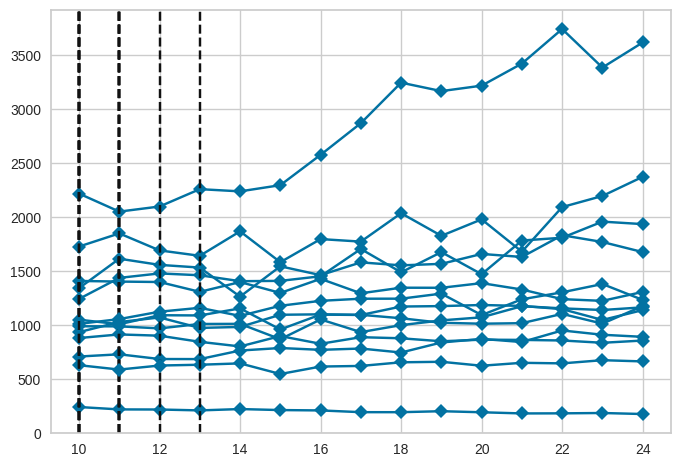

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from yellowbrick.cluster import KElbowVisualizer
from prettytable import PrettyTable
import matplotlib.pyplot as plt

# -----------------------------
# Work on copies of all features
# -----------------------------
X_train_copy = X_train_all.copy()
X_test_copy  = X_test_all.copy()

final_drop_list = []
best_cols = []

table = PrettyTable()
table.field_names = ['Original', 'Final Transformed Feature', 'Accuracy(CV) - Logistic Regression']

threshold = 0.8  # correlation threshold


num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
original_numeric_cols = num_cols  # your original numeric features
all_numeric_cols = X_train_all.select_dtypes(include=['int64', 'float64']).columns

# Derived numeric features are numeric columns not in original numeric list
num_derived_list = [c for c in all_numeric_cols if c not in original_numeric_cols]
# -----------------------------
# Loop over numeric parent features
# -----------------------------
for col in num_cols:
    # 1️⃣ Derived features related to this numeric parent
    sub_set = [f for f in num_derived_list if col in f]
    existing = [f for f in X_train_copy.columns if f in sub_set]
    
    if not existing:
        continue  # skip if no derived features
    
    # 2️⃣ Find highly correlated pairs
    correlated_features = []
    for i, f1 in enumerate(existing):
        for j in range(i + 1, len(existing)):
            if np.abs(X_train_copy[f1].corr(X_train_copy[existing[j]])) > threshold:
                correlated_features.append(existing[j])
    correlated_features = list(set(correlated_features))
    
    if len(correlated_features) > 1:
        # 3️⃣ Scale and impute
        temp_train = X_train_copy[correlated_features].fillna(0)
        temp_test = X_test_copy[correlated_features].fillna(0)
        
        scaler = StandardScaler()
        temp_train_scaled = scaler.fit_transform(temp_train)
        temp_test_scaled  = scaler.transform(temp_test)
        
        # 4️⃣ PCA
        pca = TruncatedSVD(n_components=1, random_state=42)
        x_pca_train = pca.fit_transform(temp_train_scaled)
        x_pca_test  = pca.transform(temp_test_scaled)
        
        pca_col = f"{col}_pca_final"
        X_train_copy[pca_col] = x_pca_train
        X_test_copy[pca_col]  = x_pca_test
        
        # 5️⃣ Clustering
        model = KMeans(random_state=42)
        visualizer = KElbowVisualizer(model, k=(10, 25), metric='calinski_harabasz', timings=False)
        visualizer.fit(temp_train_scaled)
        ideal_clusters = visualizer.elbow_value_ or 10
        kmeans = KMeans(n_clusters=ideal_clusters, random_state=42)
        kmeans.fit(temp_train_scaled)
        labels_train = kmeans.labels_
        labels_test  = kmeans.predict(temp_test_scaled)
        
        cluster_col = f"{col}_cluster_final"
        cluster_mean = np.log1p(
            pd.DataFrame({
                'cluster': labels_train,
                'target': y_train_int.values.ravel()  # <-- flatten to 1D
            })
            .groupby('cluster')['target']
            .mean()
        )
        cluster_dict = cluster_mean.to_dict()
        X_train_copy[cluster_col] = pd.Series(labels_train).map(cluster_mean.to_dict()).fillna(0)
        X_test_copy[cluster_col]  = pd.Series(labels_test).map(cluster_mean.to_dict()).fillna(0)

        
        # 6️⃣ Evaluate features using CV Logistic Regression
        eval_features = correlated_features + [pca_col, cluster_col]
        acc_list = []
        for f in eval_features:
            X_feat = X_train_copy[[f]].fillna(0).values
            y_array = y_train_int.values.ravel()
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            cv_acc = []
            for train_idx, val_idx in kf.split(X_feat, y_array):
                X_tr, X_val = X_feat[train_idx], X_feat[val_idx]
                y_tr, y_val = y_array[train_idx], y_array[val_idx]
                model = LogisticRegression()
                model.fit(X_tr, y_tr)
                y_pred = model.predict_proba(X_val)[:, 1]
                cutoff = acc_cutoff(y_val, y_pred)
                y_pred_bin = (y_pred > cutoff).astype(int)
                cv_acc.append(accuracy_score(y_val, y_pred_bin))
            acc_list.append((f, np.mean(cv_acc)))
        
        # 7️⃣ Select best feature
        best_col, best_acc = sorted(acc_list, key=lambda x: x[1], reverse=True)[0]
        best_cols.append(best_col)
        
        # Drop other correlated features
        drop_cols = [f for f in eval_features if f != best_col]
        final_drop_list += drop_cols
        
        table.add_row([col, best_col, best_acc])
    else:
        table.add_row([col, "All features selected", "--"])

print(table)
print("Features to drop:", final_drop_list)

# -----------------------------
# Drop the other correlated features from copies
# -----------------------------
X_train_final = X_train_copy.drop(columns=final_drop_list)
X_test_final  = X_test_copy.drop(columns=final_drop_list)

print(f"Final dataset shape after correlated feature elimination: {X_train_final.shape}")


**Method 3: based on feature Importance**

In [195]:
#

### Feature Selection (RFE-CV)

RFECV is a technique for automated feature selection that combines recursive feature elimination and cross-validation to identify the optimal subset of features for a given machine learning task.

<mark>Note: RFE-CV takes a lot of time. Here n_estimators are reduced to save time. When originally used, it is recommended to run with the actual hyperparameters.</mark>

**When might you still use RFECV?**
- You have very few features (<50) and want guaranteed univariate elimination.
- You’re using a non-tree model like linear/logistic regression or SVM.

In [ ]:
import numpy as np
import pandas as pd
from copy import deepcopy
from sklearn.feature_selection import RFECV

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


def rfecv_feature_selection(
    X_train,
    y_train,
    scoring="roc_auc",
    min_features_to_select=10,
    step=1,
    cv=2,
    consensus_threshold=2,
    random_state=42,
    verbose=True
):

    # ----------------------------
    # Define models
    # ----------------------------

    models = {
        "xgb": XGBClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1,
            tree_method="hist",
            eval_metric="logloss"
        ),

        "lgb": LGBMClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        ),

        "cat": CatBoostClassifier(
            iterations=200,
            random_state=random_state,
            verbose=False
        )
    }

    # Work on copies (important)
    X = X_train.copy()
    y = y_train.copy()

    results = {}
    all_removed = []

    # ----------------------------
    # Run RFECV for each model
    # ----------------------------

    for name, model in models.items():

        if verbose:
            print(f"\n{'='*60}")
            print(f"Running RFECV for {name}")
            print(f"{'='*60}")

        selector = RFECV(
            estimator=model,
            step=step,
            min_features_to_select=min_features_to_select,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        selector.fit(X, y)

        support_mask = selector.get_support()

        selected_features = list(X.columns[support_mask])
        removed_features = list(X.columns[~support_mask])

        idx = np.argmax(selector.cv_results_["mean_test_score"])

        mean_score = selector.cv_results_["mean_test_score"][idx]
        std_score = selector.cv_results_["std_test_score"][idx]

        if verbose:
            print(f"Best {scoring}: {mean_score:.5f} ± {std_score:.5f}")
            print(f"Selected features: {len(selected_features)}")
            print(f"Removed features: {removed_features}")

        results[name] = {
            "rfecv_model": deepcopy(selector),
            "selected_features": selected_features,
            "removed_features": removed_features,
            "best_score_mean": mean_score,
            "best_score_std": std_score
        }

        all_removed.extend(removed_features)

    # ----------------------------
    # Consensus Feature Removal
    # ----------------------------

    features, counts = np.unique(all_removed, return_counts=True)

    drop_features = list(features[counts >= consensus_threshold])

    if verbose:
        print("\n" + "="*60)
        print("Consensus Feature Removal")
        print("="*60)
        print(f"Features recommended to drop (>= {consensus_threshold} models):")
        print(drop_features)

    return results, drop_features


def plot_recursive_feature_elimination(elimination, scoring, min_features_to_select, name):
    """
    Plot RFECV results: mean test score ± std for number of features selected.
    """
    n_scores = len(elimination.cv_results_["mean_test_score"])
    plt.figure(figsize=(10, 4))
    plt.xlabel("Number of features selected")
    plt.ylabel(f"{scoring}")

    plt.errorbar(
        range(min_features_to_select, n_scores + min_features_to_select),
        elimination.cv_results_["mean_test_score"],
        yerr=elimination.cv_results_["std_test_score"],
        fmt='o-',
        capsize=3,
        markersize=4,
    )

    plt.title(f"{name} Recursive Feature Elimination", fontweight='bold')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
results, drop_features = rfecv_feature_selection(
    X_train,
    y_train,
    scoring="roc_auc",
    min_features_to_select=10,
    cv=2
)


# Plot RFECV results for each model
for name, res in results.items():
    plot_recursive_feature_elimination(
        res["rfecv_model"],
        scoring="roc_auc",
        min_features_to_select=10,
        name=name
    )
# X_train_selected = X_train.drop(columns=drop_features)
# X_test_selected  = X_test.drop(columns=drop_features)

# results["xgb"]["removed_features"]
# results["lgb"]["selected_features"]
# results["cat"]["best_score_mean"]


Running RFECV for xgb
Best roc_auc: 0.95027 ± 0.00153
Selected features: 12
Removed features: ['RNF']

Running RFECV for lgb
[LightGBM] [Info] Number of positive: 1074, number of negative: 67140
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 944
[LightGBM] [Info] Number of data points in the train set: 68214, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015745 -> initscore=-4.135390
[LightGBM] [Info] Start training from score -4.135390
[LightGBM] [Info] Number of positive: 1074, number of negative: 67141
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

### Iterative Feature Elimination with Model Importance.

**This is 10–100x faster than RFECV.**

better for large data with many features


Here’s why:

1. **RFECV is slow**

   * It trains the model from scratch **once per feature per fold**.
   * With hundreds of features and 5-fold CV, it becomes painfully slow.

2. **RFECV is unstable with tree-based models**

   * Tree models (LightGBM, CatBoost, XGBoost) already have internal feature importance.
   * RFECV can sometimes drop important features because of CV randomness.

3. **Importance-based elimination is faster and more stable**

   * You train **once per iteration**, drop worst features based on importance, and repeat.
   * Works especially well with **ensembles or stacking**, because you can keep OOF predictions stable.

4. **Top Kaggle competitors rarely use RFECV**

   * They prefer **model-based iterative pruning** (sometimes combined with SHAP values).


**THINGS U COULD ADD**

🟢 1. Stability selection (bootstrap survival rate)
🟡 2. Feature clustering + group pruning
🔴 3. Leakage detection layer

In [62]:
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold


def iterative_feature_selection_kaggle(
    X_train,
    y_train,
    scoring="auc",
    drop_fraction=0.2,
    min_features=20,
    n_splits=5,
    random_state=42,
    importance_rounds=3,
    early_stop_patience=2
):

    X = X_train.copy()
    features = list(X.columns)

    history = []
    best_score = -np.inf
    no_improve_rounds = 0

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    while len(features) > min_features:

        fold_importances = pd.DataFrame(index=features)
        fold_scores = []

        # =========================
        # CV training (stable importance)
        # =========================
        for train_idx, val_idx in skf.split(X, y_train):

            X_tr, X_val = X.iloc[train_idx][features], X.iloc[val_idx][features]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model = LGBMClassifier(
                n_estimators=800,
                learning_rate=0.05,
                num_leaves=64,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=random_state,
                n_jobs=-1
            )

            model.fit(X_tr, y_tr)

            preds = model.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, preds)
            fold_scores.append(score)

            fold_importances[f"fold_{len(fold_scores)}"] = model.feature_importances_

        mean_score = np.mean(fold_scores)

        # average importance across folds
        importance = fold_importances.mean(axis=1).sort_values()

        history.append({
            "n_features": len(features),
            "cv_score": mean_score
        })

        print(f"\n📊 Features: {len(features)} | CV: {mean_score:.5f}")

        # =========================
        # early stopping logic
        # =========================
        if mean_score > best_score:
            best_score = mean_score
            no_improve_rounds = 0
        else:
            no_improve_rounds += 1

        if no_improve_rounds >= early_stop_patience:
            print("🛑 Early stopping (no improvement)")
            break

        # =========================
        # feature pruning
        # =========================
        n_drop = max(1, int(len(features) * drop_fraction))
        worst_features = importance.index[:n_drop].tolist()

        print(f"🧹 Dropping {len(worst_features)} weakest features")

        features = [f for f in features if f not in worst_features]

    return features, history

In [68]:
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score


def kaggle_feature_selection_best(
    X_train,
    y_train,
    min_features=25,
    n_splits=3,
    drop_fraction=0.15,
    patience=2,
    random_state=42
):

    X = X_train.copy()
    features = list(X.columns)

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    best_score = -np.inf
    no_improve = 0
    history = []

    while len(features) > min_features:

        fold_scores = []
        importance_df = pd.DataFrame(index=features)

        # ======================
        # CV TRAINING LOOP
        # ======================
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y_train)):

            X_tr = X.iloc[tr_idx][features]
            X_val = X.iloc[val_idx][features]
            y_tr = y_train.iloc[tr_idx]
            y_val = y_train.iloc[val_idx]

            model = LGBMClassifier(
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=random_state,
                n_jobs=2   # 🔥 prevents laptop freeze
            )

            model.fit(X_tr, y_tr)

            preds = model.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, preds)
            fold_scores.append(score)

            importance_df[f"f{fold}"] = model.feature_importances_

        mean_score = np.mean(fold_scores)

        # ======================
        # FEATURE IMPORTANCE
        # ======================
        importance = importance_df.mean(axis=1).sort_values()

        history.append({
            "n_features": len(features),
            "cv_auc": mean_score
        })

        print(f"\n📊 Features: {len(features)} | CV AUC: {mean_score:.5f}")

        # ======================
        # EARLY STOPPING
        # ======================
        if mean_score > best_score:
            best_score = mean_score
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print("🛑 Early stopping triggered")
            break

        # ======================
        # ADAPTIVE PRUNING
        # ======================
        n_drop = max(1, int(len(features) * drop_fraction))
        worst_features = importance.index[:n_drop].tolist()

        print(f"🧹 Dropping {len(worst_features)} features")

        features = [f for f in features if f not in worst_features]

    return features, history

In [70]:
# selected_features, history = iterative_feature_selection_kaggle(
#     X_train_engineered,
#     y_train,
#     scoring="auc",
#     drop_fraction=0.2,
#     min_features=20,
#     n_splits=5
# )

selected_features, history  = kaggle_feature_selection_best(
    X_train_engineered,
    y_train,
    min_features=25,
    n_splits=3,
    drop_fraction=0.15,
    patience=2,
)

history


[LightGBM] [Info] Number of positive: 61176, number of negative: 138824
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040802 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4486
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 124
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.305880 -> initscore=-0.819452
[LightGBM] [Info] Start training from score -0.819452
[LightGBM] [Info] Number of positive: 61176, number of negative: 138824
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041876 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4490
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 124
[LightGBM] [

[{'n_features': 124, 'cv_auc': 0.7482160844047713},
 {'n_features': 106, 'cv_auc': 0.7483963242817314},
 {'n_features': 91, 'cv_auc': 0.7484358845453772},
 {'n_features': 78, 'cv_auc': 0.7482134214109148},
 {'n_features': 67, 'cv_auc': 0.7483966966801178}]

In [62]:
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier, early_stopping
from sklearn.model_selection import StratifiedKFold


# =========================================================
# 1. LIGHTGBM IMPORTANCE (STABLE + NORMALIZED)
# =========================================================
def lgbm_importance(X, y, seed=42, n_splits=5):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    importance = pd.DataFrame(index=X.columns)

    for fold, (tr, val) in enumerate(skf.split(X, y)):

        model = LGBMClassifier(
            n_estimators=1000,
            learning_rate=0.05,
            num_leaves=64,
            subsample=0.8,
            colsample_bytree=0.8,
            importance_type='gain',   # 🔥 key upgrade
            random_state=seed,
            n_jobs=2                  # ⚠️ prevent freezing
        )

        model.fit(
            X.iloc[tr], y.iloc[tr],
            eval_set=[(X.iloc[val], y.iloc[val])],
            eval_metric='auc',
            callbacks=[early_stopping(50, verbose=False)]
        )

        importance[f"fold_{fold}"] = model.feature_importances_

    # 🔥 normalization (VERY IMPORTANT)
    importance = importance.div(importance.sum(axis=0), axis=1)

    return importance.mean(axis=1).sort_values(ascending=False)


# =========================================================
# 2. STABILITY SELECTION (ADAPTIVE)
# =========================================================
def stability_selection(X, y, seeds=[0, 42, 99], keep_ratio=0.7):

    feature_scores = pd.DataFrame(index=X.columns)

    for seed in seeds:
        imp = lgbm_importance(X, y, seed=seed)
        feature_scores[f"seed_{seed}"] = imp

    # 🔥 mean importance across seeds
    mean_imp = feature_scores.mean(axis=1)

    # 🔥 adaptive threshold (not fixed top_k)
    threshold = mean_imp.quantile(1 - keep_ratio)

    selected = mean_imp[mean_imp >= threshold].index.tolist()

    # 🔥 stability score (how often important)
    stability = (feature_scores.rank(ascending=False) <= int(len(X.columns)*keep_ratio)).mean(axis=1)

    return selected, stability.sort_values(ascending=False)


# =========================================================
# 3. FAST CORRELATION PRUNING
# =========================================================
def correlation_filter(X, features, threshold=0.95):

    X_sub = X[features]

    corr = X_sub.corr().abs()

    to_drop = set()

    for i in range(len(corr.columns)):
        for j in range(i):
            if corr.iloc[i, j] > threshold:
                col = corr.columns[i]
                if col not in to_drop:
                    to_drop.add(col)

    kept = [f for f in features if f not in to_drop]

    return kept, list(to_drop)


# =========================================================
# 4. FINAL HYBRID PIPELINE
# =========================================================
def hybrid_feature_selection(
    X_train,
    y_train,
    seeds=[0, 42, 99],
    stability_threshold=0.6,
    corr_threshold=0.95
):

    print("🔥 Step 1: Stability selection...")

    selected, stability = stability_selection(
        X_train,
        y_train,
        seeds=seeds
    )

    # 🔥 apply stability threshold
    stable_features = [
        f for f in selected if stability[f] >= stability_threshold
    ]

    print(f"✔ Stable features: {len(stable_features)}")

    print("🔥 Step 2: Correlation pruning...")

    final_features, dropped_corr = correlation_filter(
        X_train,
        stable_features,
        threshold=corr_threshold
    )

    print(f"✔ Final features: {len(final_features)}")
    print(f"🧹 Dropped (correlation): {len(dropped_corr)}")

    return final_features, stability, dropped_corr

In [63]:
selected_features, stability_scores, dropped_corr = hybrid_feature_selection(
    X_train_engineered,
    y_train,
    seeds=[0, 42, 99], # if daata is large use only two
    stability_threshold=0.6,
    corr_threshold=0.95
)

🔥 Step 1: Stability selection...
[LightGBM] [Info] Number of positive: 73412, number of negative: 166588
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4488
[LightGBM] [Info] Number of data points in the train set: 240000, number of used features: 124
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.305883 -> initscore=-0.819436
[LightGBM] [Info] Start training from score -0.819436
[LightGBM] [Info] Number of positive: 73411, number of negative: 166589
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4487
[LightGBM] [Info] Number of data points in the train set: 240000, number o

In [ ]:
X_train_engineered[selected_features].to_csv("../data/X_train_fe.csv", index=False)
X_test_engineered[selected_features].to_csv("../data/X_test_fe.csv", index=False)

# ✔ Stable features: 84
# 🔥 Step 2: Correlation pruning...
# ✔ Final features: 74
# 🧹 Dropped (correlation): 10

In [ ]:
X_train_final = X_train_engineered[selected_features]
X_test_final  = X_test_engineered[selected_features]

**Add PCA ONLY on rejected features**

In [ ]:
from sklearn.decomposition import PCA

rejected = [c for c in X_train_all.columns if c not in features]

pca = PCA(n_components=5, random_state=42)

X_train_pca = pca.fit_transform(X_train_all[rejected])
X_test_pca  = pca.transform(X_test_all[rejected])

for i in range(X_train_pca.shape[1]):
    X_train_all[f"pca_{i}"] = X_train_pca[:, i]
    X_test_all[f"pca_{i}"]  = X_test_pca[:, i]

#  Less Important Features


There are a lot of features created and many of them are not important/highly correlated, the first level of reduction is to create subsets based on the original features, apply PCA to select PC1 and drop the subset

💡 Summary of what this code does:

- For each numeric column in cont_cols, find all its “unimportant features” in unimportant_features.

- Scale them using StandardScaler.

- Reduce them to 1 combined feature using TruncatedSVD (similar to PCA).

- Add this new combined feature to your train and test datasets.

- Drop the original unimportant features to reduce dimensionality.

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import TruncatedSVD
# from prettytable import PrettyTable

# # -----------------------------
# # Work on copies of train/test
# # -----------------------------
# X_train_copy = X_train_all.copy()
# X_test_copy  = X_test_all.copy()

# final_drop_list = []  # to store unimportant features that will be dropped
# new_pca_cols = []     # to store new PCA features created

# table = PrettyTable()
# table.field_names = ['Original Parent Feature', 'PCA Feature Created']

# # -----------------------------
# # Define continuous columns
# # -----------------------------
# cont_cols = X_train_all.select_dtypes(include=['int64', 'float64']).columns.tolist()

# # -----------------------------
# # Loop over continuous parent features
# # -----------------------------
# for col in cont_cols:
#     # 1️⃣ Find all unimportant features related to this parent
#     sub_set = [f for f in unimportant_features if col in f]
#     existing = [f for f in X_train_copy.columns if f in sub_set]
    
#     if not existing:
#         continue  # skip if no features to combine
    
#     # 2️⃣ Scale features
#     temp_train = X_train_copy[existing].fillna(0)
#     temp_test  = X_test_copy[existing].fillna(0)
    
#     scaler = StandardScaler()
#     temp_train_scaled = scaler.fit_transform(temp_train)
#     temp_test_scaled  = scaler.transform(temp_test)
    
#     # 3️⃣ Apply TruncatedSVD to reduce to 1 component
#     svd = TruncatedSVD(n_components=1, random_state=42)
#     x_pca_train = svd.fit_transform(temp_train_scaled)
#     x_pca_test  = svd.transform(temp_test_scaled)
    
#     # 4️⃣ Add PCA feature to train/test
#     pca_col = f"{col}_pca_comb_unimp"
#     X_train_copy[pca_col] = x_pca_train
#     X_test_copy[pca_col]  = x_pca_test
#     new_pca_cols.append(pca_col)
    
#     # 5️⃣ Drop original unimportant features (except the parent continuous column)
#     for f in sub_set:
#         if f in X_train_copy.columns and f not in cont_cols:
#             X_train_copy.drop(columns=[f], inplace=True)
#             X_test_copy.drop(columns=[f], inplace=True)
#             final_drop_list.append(f)
    
#     table.add_row([col, pca_col])

# # -----------------------------
# # Display results
# # -----------------------------
# print(table)
# print("Original unimportant features dropped:", final_drop_list)
# print("New PCA features created:", new_pca_cols)
# print(f"Final train shape: {X_train_copy.shape}, test shape: {X_test_copy.shape}")


+-------------------------+---------------------+
| Original Parent Feature | PCA Feature Created |
+-------------------------+---------------------+
+-------------------------+---------------------+
Original unimportant features dropped: []
New PCA features created: []
Final train shape: (6954, 101), test shape: (1739, 101)


# PCA

Just for fun, let's look at the transformed data in PCA space. This gives a low dimensional representation of the data, which preserves local and global structure.


In [45]:
from sklearn.decomposition import PCA
import plotly.express as px

# 1️⃣ Select numeric features only
numeric_cols = X_train_all.select_dtypes(include=['int64', 'float64']).columns
X_train_numeric = X_train_all[numeric_cols]

# 2️⃣ Apply PCA
pca = PCA(n_components=3)
components = pca.fit_transform(X_train_numeric)

total_var = pca.explained_variance_ratio_.sum() * 100

# 3️⃣ 3D scatter plot
fig = px.scatter_3d(
    x=components[:, 0],
    y=components[:, 1],
    z=components[:, 2],
    color=y_train_enc,  # target
    size=0.1*np.ones(len(X_train_numeric)),
    opacity=1,
    title=f'Total Explained Variance: {total_var:.2f}%',
    labels={'x': 'PC 1', 'y': 'PC 2', 'z': 'PC 3'},
    width=800, height=500
)
fig.show()


ValueError: Input X contains NaN, infinity or a value too large for dtype('float64').

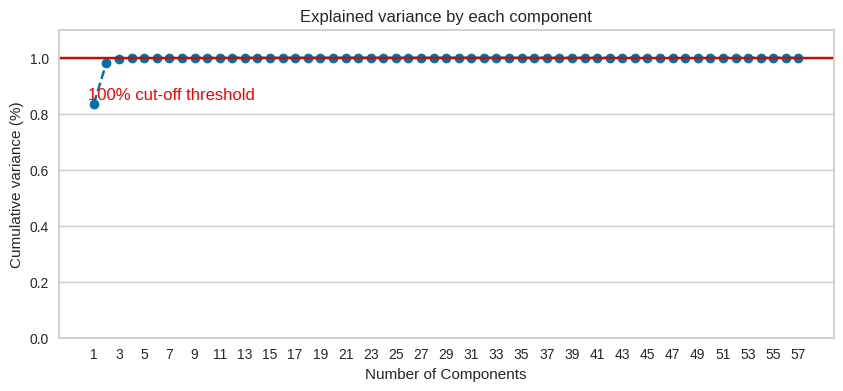

In [209]:
# Explained variance (how important each additional principal component is)
pca = PCA().fit(X_train_numeric)
fig, ax = plt.subplots(figsize=(10,4))
xi = np.arange(1, 1+X_train_numeric.shape[1], step=1)
yi = np.cumsum(pca.explained_variance_ratio_)
plt.plot(xi, yi, marker='o', linestyle='--', color='b')

# Aesthetics
plt.ylim(0.0,1.1)
plt.xlabel('Number of Components')
plt.xticks(np.arange(1, 1+X_train_numeric.shape[1], step=2))
plt.ylabel('Cumulative variance (%)')
plt.title('Explained variance by each component')
plt.axhline(y=1, color='r', linestyle='-')
plt.text(0.5, 0.85, '100% cut-off threshold', color = 'red')
ax.grid(axis='x')

**RFE with xgboosst**

In [ ]:


from sklearn.feature_selection import RFECV
import xgboost as xgb



X_train, X_val, y_train, y_val = train_test_split(X_train, y_train_int, test_size=0.2, random_state=42, stratify=y)

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    random_state=42,
    eval_metric='mlogloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=model_xgb,
    step=1,
    cv=cv,
    scoring='accuracy',
    min_features_to_select=5
)

rfecv.fit(X_train, y_train)

# Plot RFECV performance
plt.figure(figsize=(8, 5))
plt.title("RFECV - Number of Features vs CV Accuracy")
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validated Accuracy")
plt.plot(
    range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    rfecv.cv_results_['mean_test_score'],
    marker='o'
)
plt.show()

selected_features = X_train.columns[rfecv.support_]
print("Selected Features:")
print(selected_features)



In [ ]:
X_train_all.to_csv('../data/X_train_fg.csv', index=False)
X_test_all.to_csv('../data/X_test_fg.csv', index=False)
y_train.to_csv('../data/y_train_fg.csv', index=False)
y_test.to_csv('../data/y_test_fg.csv', index=False)
